In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linprog

## Import des données temporelles

Cette partie ne foncitonne qu'en local sur mon PC, les chemin d'accès des fichiers ci-dessous doit être modifié pour fonctionner correctement 

In [41]:
donnees_secondes_raw = pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-1.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]
donnees_secondes_raw = pd.concat([donnees_secondes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-2.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)
donnees_secondes_raw = pd.concat([donnees_secondes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-3.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)
donnees_secondes_raw = pd.concat([donnees_secondes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-4.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)
donnees_secondes_raw = pd.concat([donnees_secondes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-5.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)
donnees_secondes_raw = pd.concat([donnees_secondes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-6.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)
donnees_secondes_raw = pd.concat([donnees_secondes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-7.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)
donnees_secondes_raw = pd.concat([donnees_secondes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-8.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)
donnees_secondes_raw = pd.concat([donnees_secondes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-9.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)
donnees_secondes_raw = pd.concat([donnees_secondes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-10.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)

donnees_minutes_raw = pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T115638-1-1.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]
donnees_minutes_raw = pd.concat([donnees_minutes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T115638-1-2.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)

C:\Users\a.jehanno\AppData\Local\Temp\ipykernel_27580\1152712643.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  donnees_secondes_raw = pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-1.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]
C:\Users\a.jehanno\AppData\Local\Temp\ipykernel_27580\1152712643.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  donnees_secondes_raw = pd.concat([donnees_secondes_raw,pd.read_csv(r"C:/Users/a.jehanno/Documents/Donnees/CSD analyse-20250914T112543-1-2.csv",sep=";", encoding="latin1").iloc[4:, [0, 2, 4]]], axis=0, ignore_index = True)
C:\Users\a.jehanno\AppData\Local\Temp\ipykernel_27580\1152712643.py:3: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  donnees

In [3]:
# Débits de dimensionnement de la centrale, le débit mesuré est toujours inférieur à ces valeurs

DEBIT_MAX_CHAMPSEC = 208.1      # m³/h
DEBIT_MAX_HOPITAL = 132.1       # m³/h
DEBIT_MAX_STEP_4 = 18.4/4.18/30 * 3600    # m³/h  
# Le débit de dimensionnement de la STEP en mode 4 est le débit que les trois chaudières de 5 MW + les deux PACs de 1.7 MW produisent, soit Q = P/(c_p * dT) avec P = 18.4
# En mode 4, la chaleur est produite uniquement à la STEP et distribuée vers Conthey et Sion

print("Le débit max d'eau à en 85/55°C produit par la STEP en mode 4 est de :", round(DEBIT_MAX_STEP_4, 2), " m3/h")

DEBIT_TOTAL_MAX_CAD = DEBIT_MAX_CHAMPSEC + DEBIT_MAX_HOPITAL

# Quantile de stockage pour une production 100% sur les PACs pour au moins une journée
QUANTILE_STOCKAGE_STEP = 3.4/4.18/30 * 3600 / DEBIT_MAX_STEP_4


QUANTILE_STOCKAGE_CAD = 0.70
QUANTILE_STOCKAGE_TOTAL = 0.80
# QUANTILE_STOCKAGE_STEP = 0.85

FACTEUR_SECURITE_FLUCTUATIONS = 2

DUREES_MAINTIEN_MIN = [0.5, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 60]

Le débit max d'eau à en 85/55°C produit par la STEP en mode 4 est de : 528.23  m3/h


In [39]:
### Fonctions utilisées 
## L'ancienne version ne

In [4]:
def preparer_donnees_temporelles(df_raw, unite_temps="min"):
    """
    Prépare les données brutes :
    - copie du DataFrame ;
    - renommage des colonnes ;
    - conversion de la date ;
    - conversion des débits en numérique ;
    - ajout d'un temps relatif.
    """

    df = df_raw.copy()

    df.columns = ["Date", "Débit Hôpital", "Débit Champsec"]

    df["Date"] = pd.to_datetime(df["Date"])

    df["Débit Hôpital"] = pd.to_numeric(
        df["Débit Hôpital"],
        errors="coerce"
    )

    df["Débit Champsec"] = pd.to_numeric(
        df["Débit Champsec"],
        errors="coerce"
    )

    t0 = df["Date"].min()

    if unite_temps == "min":
        df["Temps_min"] = (df["Date"] - t0).dt.total_seconds() / 60

    elif unite_temps == "s":
        df["Temps_s"] = (df["Date"] - t0).dt.total_seconds()

    else:
        raise ValueError("L'unité de temps doit être 'min' ou 's'.")

    return df

def calculer_jour_type(df, colonne_debit):
    """
    Calcule la journée type minute par minute :
    - moyenne ;
    - écart-type ;
    - nombre de points ;
    - intervalle de confiance à 90 %.
    """

    stats = (
        df
        .groupby("Minute journalière")[colonne_debit]
        .agg(["mean", "std", "count"])
    )

    stats["IC_inf"] = (
        stats["mean"]
        - 1.645 * stats["std"] / np.sqrt(stats["count"])
    )

    stats["IC_sup"] = (
        stats["mean"]
        + 1.645 * stats["std"] / np.sqrt(stats["count"])
    )

    return stats


def calculer_stockage_au_dessus_quantile(serie_debit, quantile_stockage):
    """
    Calcule :
    - le seuil de stockage correspondant au quantile choisi ;
    - l'excès au-dessus du seuil ;
    - le volume journalier à stocker ;
    - la durée totale du pic au-dessus du seuil.

    Hypothèse :
    - la série est au pas de temps de 1 minute ;
    - le débit est en m³/h ;
    - donc le volume est obtenu par somme(Q) / 60.
    """

    seuil = serie_debit.quantile(quantile_stockage)

    exces = (serie_debit - seuil).clip(lower=0)

    volume_stockage_m3 = exces.sum() / 60

    duree_pic_min = (serie_debit > seuil).sum()

    return seuil, exces, volume_stockage_m3, duree_pic_min


def tracer_jour_type(stats, titre, ylabel="Débit [m³/h]", afficher_ic=True):
    """
    Trace une journée type avec éventuellement son intervalle de confiance.
    """

    plt.figure(figsize=(15, 5))

    plt.plot(
        stats.index / 60,
        stats["mean"],
        label="Jour type moyen",
        linewidth=2
    )

    if afficher_ic:
        plt.fill_between(
            stats.index / 60,
            stats["IC_inf"],
            stats["IC_sup"],
            alpha=0.3,
            label="IC 90 %"
        )

    plt.xlim([0, 24])
    plt.ylim([stats["mean"].min() * 0.9, stats["mean"].max() * 1.1])

    plt.title(titre)
    plt.xlabel("Heure de la journée")
    plt.ylabel(ylabel)
    plt.grid()
    plt.legend()
    plt.show()


def tracer_debit_avec_seuil(serie_debit, seuil, titre):
    """
    Trace une série de débit journalier avec son seuil de stockage.
    """

    plt.figure(figsize=(15, 5))

    plt.plot(
        serie_debit.index / 60,
        serie_debit,
        label="Jour type moyen",
        linewidth=3
    )

    plt.plot(
        serie_debit.index / 60,
        seuil * np.ones(len(serie_debit)),
        label="Seuil de stockage",
        linestyle="--"
    )

    plt.xlim([0, 24])

    plt.title(titre)
    plt.xlabel("Heure de la journée")
    plt.ylabel("Débit [m³/h]")
    plt.grid()
    plt.legend()
    plt.show()


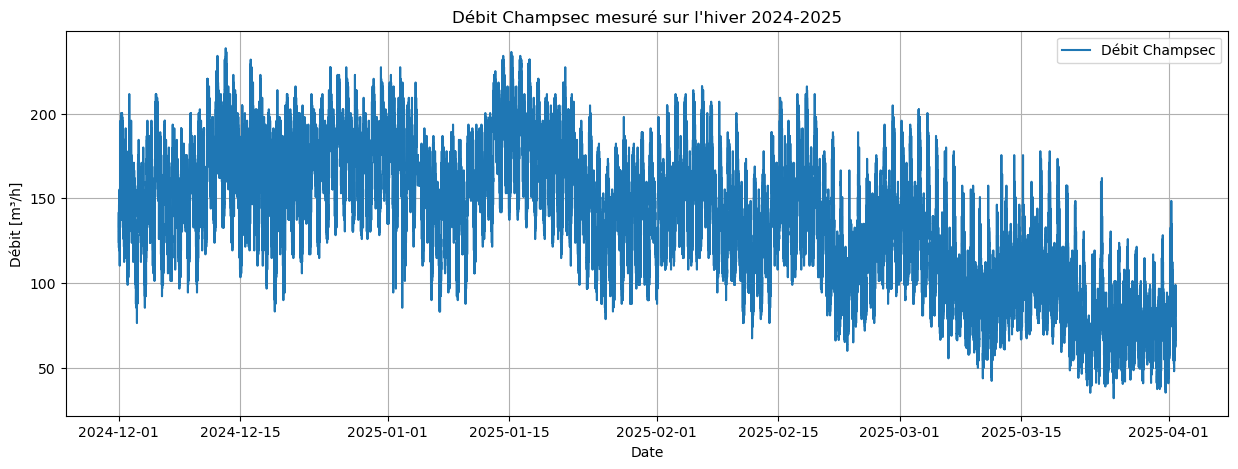

In [5]:
## Analyse de la consommation du CAD Champsec pendant un hiver avec données minute par minute

donnees_minutes = preparer_donnees_temporelles(
    donnees_minutes_raw,
    unite_temps="min"
)

donnees_secondes = preparer_donnees_temporelles(
    donnees_secondes_raw,
    unite_temps="s"
)

# Minute dans la journée, entre 0 et 1440 min
donnees_minutes["Minute journalière"] = (
    donnees_minutes["Temps_min"] % (24 * 60)
)

# Débit total CAD
donnees_minutes["Débit total"] = (
    donnees_minutes["Débit Champsec"]
    + donnees_minutes["Débit Hôpital"]
)

plt.figure(figsize=(15, 5))

plt.plot(
    donnees_minutes["Date"],
    donnees_minutes["Débit Champsec"],
    label="Débit Champsec"
)

plt.title("Débit Champsec mesuré sur l'hiver 2024-2025")
plt.xlabel("Date")
plt.ylabel("Débit [m³/h]")
plt.grid()
plt.legend()
plt.show()


                          mean        std  count      IC_inf      IC_sup
Minute journalière                                                      
0.0                 110.107377  28.530952    122  105.858225  114.356529
1.0                 110.468852  28.085601    122  106.286027  114.651678
2.0                 110.400820  29.135547    122  106.061625  114.740015
3.0                 110.994262  29.334016    122  106.625509  115.363016
4.0                 111.314754  29.977338    122  106.850190  115.779318
...                        ...        ...    ...         ...         ...
1435.0              108.389256  27.504999    121  104.276009  112.502504
1436.0              109.312397  27.948752    121  105.132788  113.492006
1437.0              109.485950  27.791345    121  105.329881  113.642020
1438.0              109.388430  28.139629    121  105.180276  113.596583
1439.0              110.106612  28.196547    121  105.889946  114.323277

[1440 rows x 5 columns]


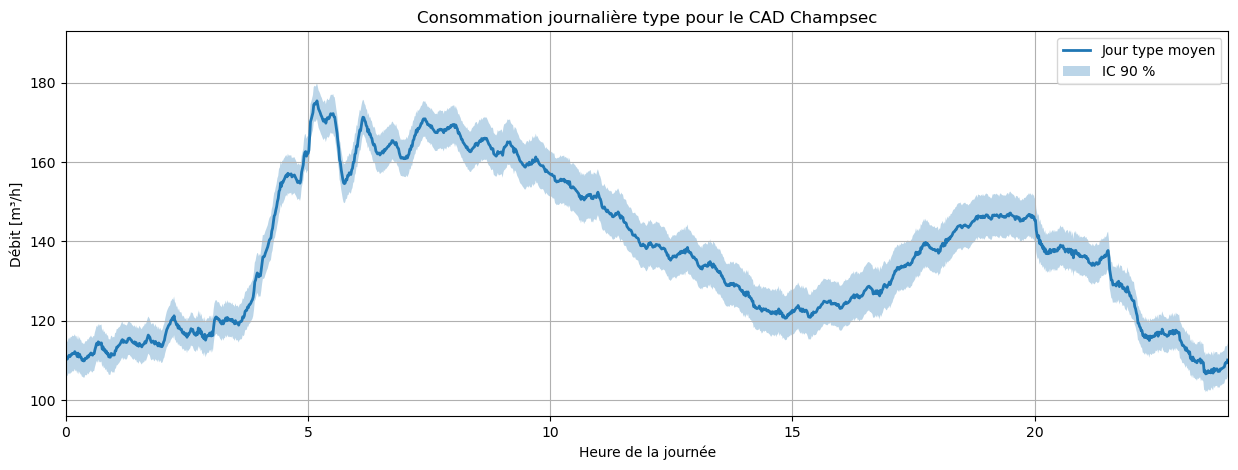

In [6]:
## Création du profil de consommation journalière type du CAD Champsec
stats_jour_champsec = calculer_jour_type(
    donnees_minutes,
    "Débit Champsec"
)

stats_jour_hopital = calculer_jour_type(
    donnees_minutes,
    "Débit Hôpital"
)

stats_jour_total = calculer_jour_type(
    donnees_minutes,
    "Débit total"
)

print(stats_jour_champsec)

tracer_jour_type(
    stats_jour_champsec,
    titre="Consommation journalière type pour le CAD Champsec"
)


Le volume de stockage journalier pour Champsec est de 103.9 m³
La durée du pic atténué est de 432 min, soit 7.2 heures


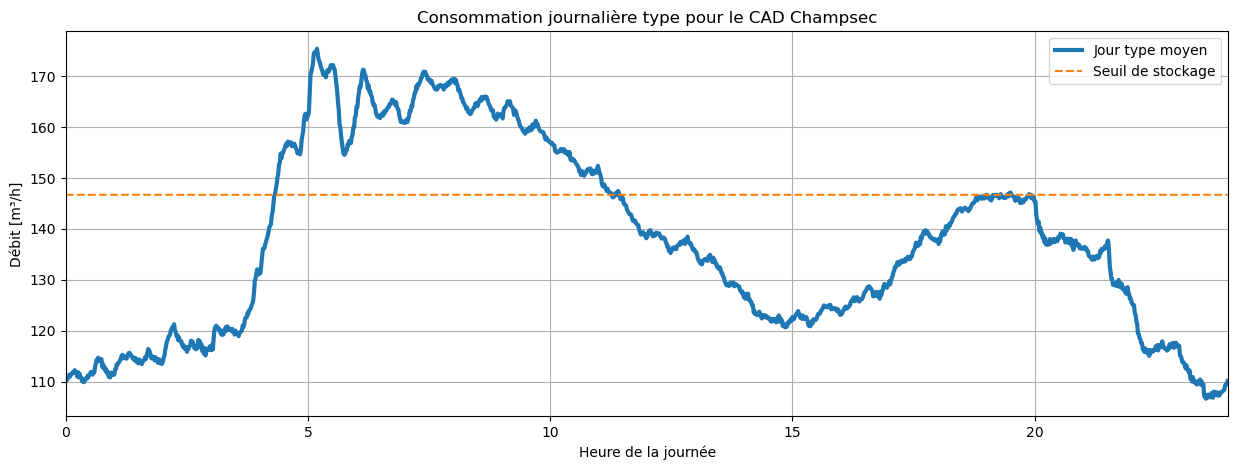

In [7]:
## Première tentative d'analyse d'atténuation de pic journalier, optimiste sur dimension de l'accu

Q_champsec = stats_jour_champsec["mean"]

seuil_champsec, exces_champsec, volume_stockage_champsec, duree_pic_champsec = (
    calculer_stockage_au_dessus_quantile(
        Q_champsec,
        QUANTILE_STOCKAGE_CAD
    )
)

print(
    "Le volume de stockage journalier pour Champsec est de",
    round(volume_stockage_champsec, 1),
    "m³"
)

print(
    "La durée du pic atténué est de",
    duree_pic_champsec,
    "min, soit",
    round(duree_pic_champsec / 60, 2),
    "heures"
)

tracer_debit_avec_seuil(
    Q_champsec,
    seuil_champsec,
    titre="Consommation journalière type pour le CAD Champsec"
)


Le volume de stockage journalier total est de 44.4 m³
La durée du pic atténué total est de 288 min, soit 4.8 heures


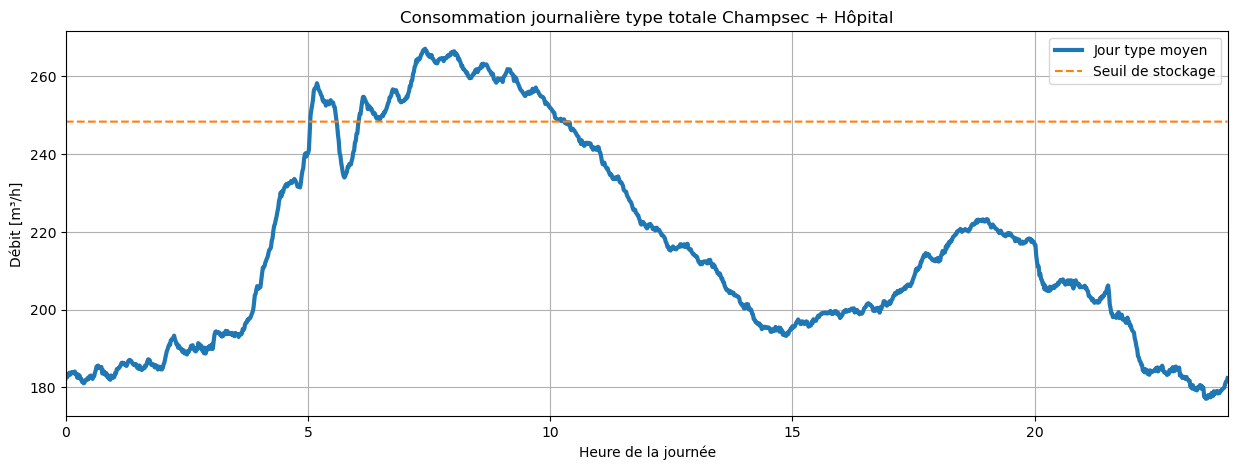

In [8]:
## Tentative d'atténuation de pic journalier de Champsec + Hôpital, conservatif sur dimension de l'accu
Q_total_CAD = stats_jour_total["mean"]

seuil_total, exces_total, volume_stockage_total, duree_pic_total = (
    calculer_stockage_au_dessus_quantile(
        Q_total_CAD,
        QUANTILE_STOCKAGE_TOTAL
    )
)

print(
    "Le volume de stockage journalier total est de",
    round(volume_stockage_total, 1),
    "m³"
)

print(
    "La durée du pic atténué total est de",
    duree_pic_total,
    "min, soit",
    round(duree_pic_total / 60, 2),
    "heures"
)

tracer_debit_avec_seuil(
    Q_total_CAD,
    seuil_total,
    titre="Consommation journalière type totale Champsec + Hôpital"
)


Le volume de stockage journalier pour la STEP 4 est de 1004.0 m³
La durée du pic atténué pour la STEP 4 est de 1174 min, soit 19.57 heures


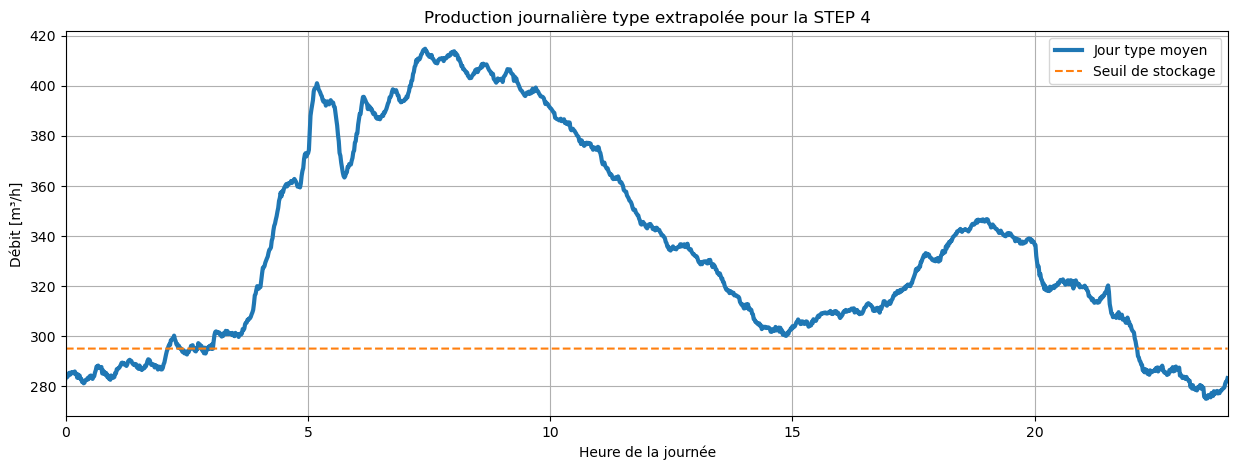

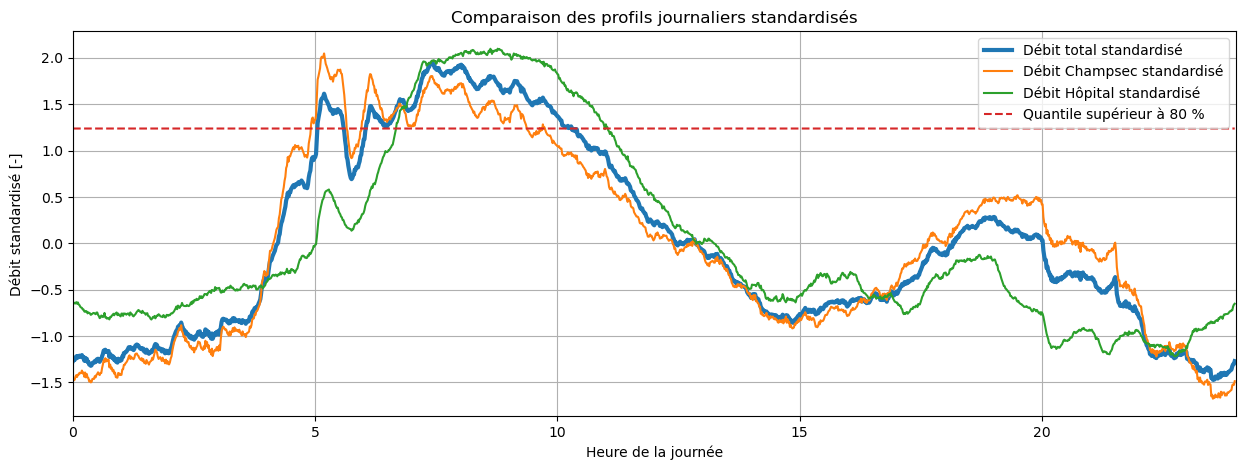

In [9]:
## Standardisation des données et extrapolation sur les statistiques de consommation de la STEP en mode 4, où le débit sortant est le plus élevé

Q_moyen_step_4 = Q_total_CAD.mean() / DEBIT_TOTAL_MAX_CAD * DEBIT_MAX_STEP_4
STD_step_4 = Q_total_CAD.std()/DEBIT_TOTAL_MAX_CAD * DEBIT_MAX_STEP_4


Q_step_4 = (Q_total_CAD-Q_total_CAD.mean())/Q_total_CAD.std() * STD_step_4 + Q_moyen_step_4

seuil_step_4, exces_step_4, volume_stockage_step_4, duree_pic_step_4 = (
    calculer_stockage_au_dessus_quantile(
        Q_step_4,
        QUANTILE_STOCKAGE_STEP
    )
)

print(
    "Le volume de stockage journalier pour la STEP 4 est de",
    round(volume_stockage_step_4, 1),
    "m³"
)

print(
    "La durée du pic atténué pour la STEP 4 est de",
    duree_pic_step_4,
    "min, soit",
    round(duree_pic_step_4 / 60, 2),
    "heures"
)

tracer_debit_avec_seuil(
    Q_step_4,
    seuil_step_4,
    titre="Production journalière type extrapolée pour la STEP 4"
)

profil_champsec_standardise = (
    Q_champsec - Q_champsec.mean()
) / Q_champsec.std()

profil_hopital_standardise = (
    stats_jour_hopital["mean"] - stats_jour_hopital["mean"].mean()
) / stats_jour_hopital["mean"].std()

profil_total_standardise = (
    Q_total_CAD - Q_total_CAD.mean()
) / Q_total_CAD.std()

seuil_standardise = profil_total_standardise.quantile(
    QUANTILE_STOCKAGE_TOTAL
)

plt.figure(figsize=(15, 5))

plt.plot(
    profil_total_standardise.index / 60,
    profil_total_standardise,
    label="Débit total standardisé",
    linewidth=3
)

plt.plot(
    profil_champsec_standardise.index / 60,
    profil_champsec_standardise,
    label="Débit Champsec standardisé"
)

plt.plot(
    profil_hopital_standardise.index / 60,
    profil_hopital_standardise,
    label="Débit Hôpital standardisé"
)

plt.plot(
    profil_total_standardise.index / 60,
    seuil_standardise * np.ones(len(profil_total_standardise)),
    label="Quantile supérieur à 80 %",
    linestyle="--"
)

plt.xlim([0, 24])
plt.title("Comparaison des profils journaliers standardisés")
plt.xlabel("Heure de la journée")
plt.ylabel("Débit standardisé [-]")
plt.grid()
plt.legend()
plt.show()


La durée médiane entre deux changements de point d'opération est de : 5.0 s
Le point d'opération change en moins de : 18.0 s dans 90 % des cas
La variation médiane de débit entre deux points d'opération est de : 2.3 m³/h
Le quantile à 99 % de la variation de débit est de : 6.8 m³/h
    Durée maintien [min]  Nombre de pas  ΔQ99 [m³/h]  Volume requis [m³]
0                    0.5              6         15.8            0.263333
1                    1.0             12         20.3            0.676667
2                    2.0             24         22.5            1.500000
3                    3.0             36         27.0            2.700000
4                    4.0             48         29.3            3.906667
5                    5.0             60         31.5            5.250000
6                   10.0            120         38.3           12.766667
7                   15.0            180         40.5           20.250000
8                   20.0            240         42.8        

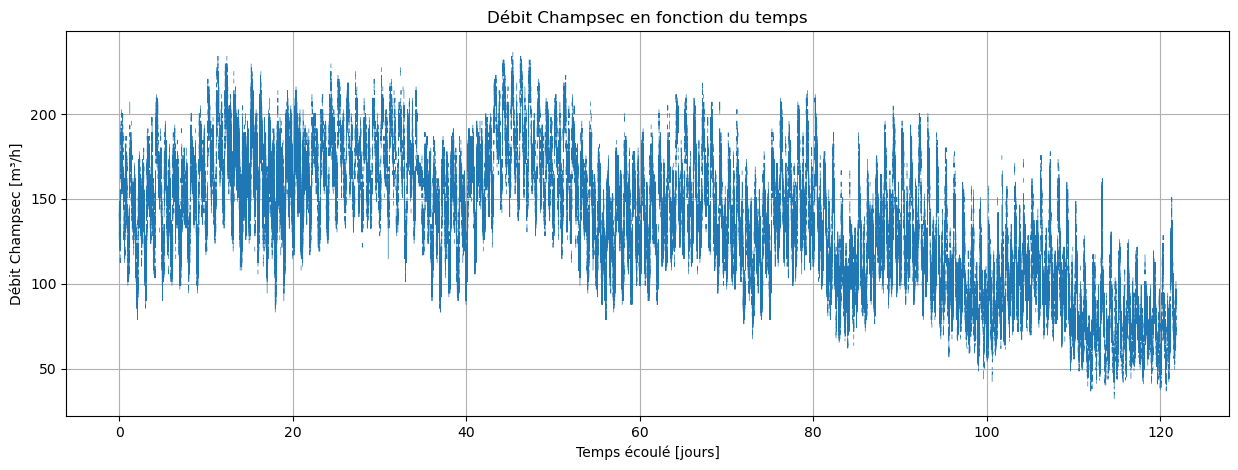

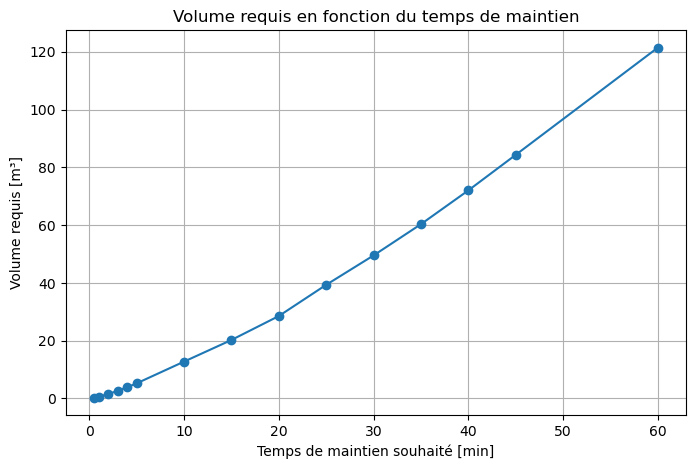

In [10]:

dt_median_s = donnees_secondes["Temps_s"].diff().median()
dt_90_s = donnees_secondes["Temps_s"].diff().quantile(0.90)

dQ_median_champsec = (
    donnees_secondes["Débit Champsec"]
    .diff()
    .abs()
    .median()
)

dQ_99_champsec = (
    donnees_secondes["Débit Champsec"]
    .diff()
    .abs()
    .quantile(0.99)
)

print(
    "La durée médiane entre deux changements de point d'opération est de :",
    round(dt_median_s, 1),
    "s"
)

print(
    "Le point d'opération change en moins de :",
    round(dt_90_s, 1),
    "s dans 90 % des cas"
)

print(
    "La variation médiane de débit entre deux points d'opération est de :",
    round(dQ_median_champsec, 2),
    "m³/h"
)

print(
    "Le quantile à 99 % de la variation de débit est de :",
    round(dQ_99_champsec, 2),
    "m³/h"
)

resultats_fluctuations = []

for duree_maintien_min in DUREES_MAINTIEN_MIN:

    duree_maintien_s = duree_maintien_min * 60

    # Nombre de pas temporels correspondant à cette durée
    nombre_pas = int(duree_maintien_s / dt_median_s)

    # Variation de débit entre deux points espacés de la durée de maintien
    delta_Q = (
        donnees_secondes["Débit Champsec"]
        - donnees_secondes["Débit Champsec"].shift(nombre_pas)
    ).abs()

    delta_Q_99 = delta_Q.quantile(0.99)

    # Volume nécessaire [m³]
    volume_requis_m3 = (
        FACTEUR_SECURITE_FLUCTUATIONS
        * delta_Q_99
        * duree_maintien_s
        / 3600
    )

    resultats_fluctuations.append({
        "Durée maintien [min]": duree_maintien_min,
        "Nombre de pas": nombre_pas,
        "ΔQ99 [m³/h]": delta_Q_99,
        "Volume requis [m³]": volume_requis_m3
    })

resultats_fluctuations = pd.DataFrame(resultats_fluctuations)

print(resultats_fluctuations)

dernier_resultat = resultats_fluctuations.iloc[-1]

print(
    "Le volume nécessaire pour atténuer 99 % des fluctuations "
    "sur une durée de",
    dernier_resultat["Durée maintien [min]"],
    "min est de",
    round(dernier_resultat["Volume requis [m³]"], 1),
    "m³, avec un facteur de sécurité de",
    FACTEUR_SECURITE_FLUCTUATIONS
)

plt.figure(figsize=(15, 5))

plt.plot(
    donnees_secondes["Temps_s"] / (3600 * 24),
    donnees_secondes["Débit Champsec"],
    linewidth=0.5
)

plt.title("Débit Champsec en fonction du temps")
plt.xlabel("Temps écoulé [jours]")
plt.ylabel("Débit Champsec [m³/h]")
plt.grid()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    resultats_fluctuations["Durée maintien [min]"],
    resultats_fluctuations["Volume requis [m³]"],
    marker="o"
)

plt.title("Volume requis en fonction du temps de maintien")
plt.xlabel("Temps de maintien souhaité [min]")
plt.ylabel("Volume requis [m³]")
plt.grid()
plt.show()

pente = np.mean(resultats_fluctuations["Volume requis [m³]"]/resultats_fluctuations["Durée maintien [min]"])

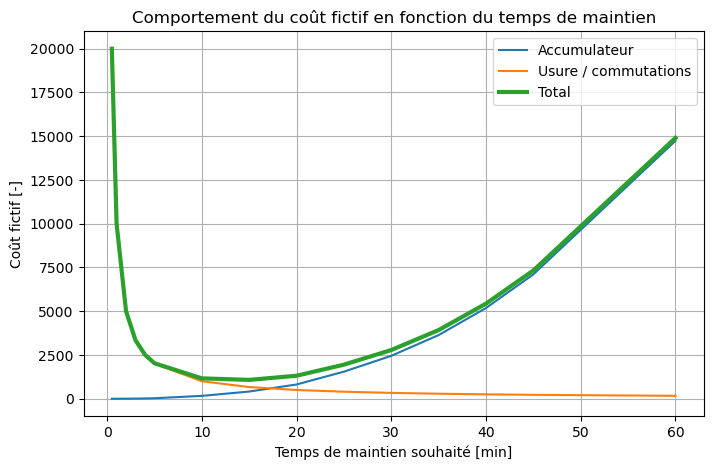

In [11]:
## Analyse de temps de maintien optimal fictif
COEFF_COUT_ACCUMULATEUR = 1
COEFF_COUT_SWITCH = 10000

resultats_fluctuations["Coût accumulateur"] = (
    COEFF_COUT_ACCUMULATEUR
    * resultats_fluctuations["Volume requis [m³]"] ** 2
)

resultats_fluctuations["Coût usure"] = (
    COEFF_COUT_SWITCH
    / resultats_fluctuations["Durée maintien [min]"]
)

resultats_fluctuations["Coût total"] = (
    resultats_fluctuations["Coût accumulateur"]
    + resultats_fluctuations["Coût usure"]
)

plt.figure(figsize=(8, 5))

plt.plot(
    resultats_fluctuations["Durée maintien [min]"],
    resultats_fluctuations["Coût accumulateur"],
    label="Accumulateur"
)

plt.plot(
    resultats_fluctuations["Durée maintien [min]"],
    resultats_fluctuations["Coût usure"],
    label="Usure / commutations"
)

plt.plot(
    resultats_fluctuations["Durée maintien [min]"],
    resultats_fluctuations["Coût total"],
    linewidth=3,
    label="Total"
)

plt.title("Comportement du coût fictif en fonction du temps de maintien")
plt.xlabel("Temps de maintien souhaité [min]")
plt.ylabel("Coût fictif [-]")
plt.grid()
plt.legend()
plt.show()


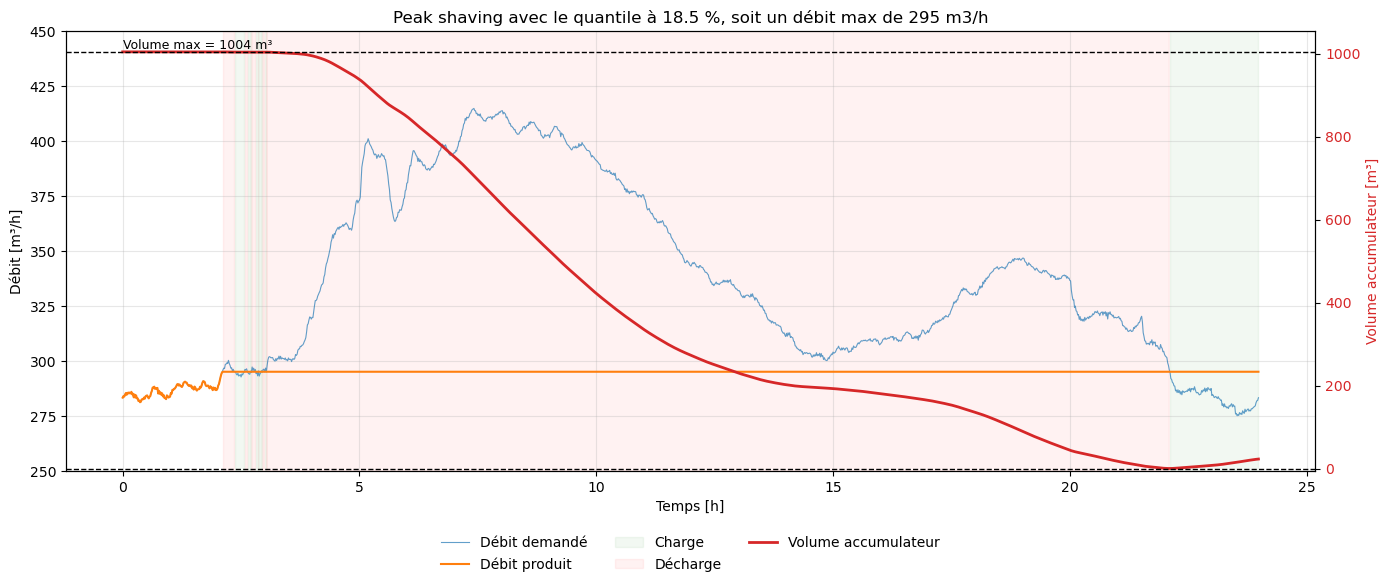

In [23]:
## Simulation du débit dans l'accumulateur

Q_sim_step_4 = Q_step_4.copy()

Q_sim_step_4.loc[Q_sim_step_4 < Q_sim_step_4.quantile(1-QUANTILE_STOCKAGE_STEP)] = Q_sim_step_4.quantile(1-QUANTILE_STOCKAGE_STEP)
Q_sim_step_4.loc[Q_sim_step_4 > Q_sim_step_4.quantile(QUANTILE_STOCKAGE_STEP)] = Q_sim_step_4.quantile(QUANTILE_STOCKAGE_STEP)
delta_Q = Q_sim_step_4 - Q_step_4

V_init_accu = volume_stockage_step_4*0.5

V_accu = V_init_accu + delta_Q.cumsum() / 60

Q_seuil = Q_step_4.quantile(QUANTILE_STOCKAGE_STEP)


V_max = volume_stockage_step_4
V_accu = V_max

Q_prod_hist = []
V_hist = []

for Q_demande in Q_step_4:

    # Cas normal : écrêtage
    Q_prod = Q_seuil

    # Mise à jour théorique du volume
    V_suivant = V_accu + (Q_prod - Q_demande) / 60

    # Accu plein
    if V_suivant > V_max:
        
        Q_prod = (V_max-V_accu) * 60 + Q_demande 
        V_suivant = V_max

    # Accu vide
    elif V_suivant < 0:

        Q_prod = Q_demande
        V_suivant = V_accu

    V_accu = V_suivant

    Q_prod_hist.append(Q_prod)
    V_hist.append(V_accu)

Q_prod_peak = pd.Series(
    Q_prod_hist,
    index=Q_step_4.index
)

V_accu_peak = pd.Series(
    V_hist,
    index=Q_step_4.index
)



fig, ax1 = plt.subplots(figsize=(14, 6))

# ==========================
# Débits
# ==========================

ax1.plot(
    Q_step_4.index / 60,
    Q_step_4,
    color="tab:blue",
    linewidth=0.8,
    alpha=0.7,
    label="Débit demandé"
)

ax1.plot(
    Q_prod_peak.index / 60,
    Q_prod_peak,
    color="tab:orange",
    linewidth=1.5,
    label="Débit produit"
)

ax1.set_xlabel("Temps [h]")
ax1.set_ylabel("Débit [m³/h]")
ax1.set_ylim([250, 450])
ax1.grid(True, alpha=0.3)

charge = Q_prod_peak > Q_step_4
decharge = Q_prod_peak < Q_step_4

ax1.fill_between(
    Q_step_4.index / 60,
    ax1.get_ylim()[0],
    ax1.get_ylim()[1],
    where=charge,
    color="green",
    alpha=0.05,
    label="Charge"
)

ax1.fill_between(
    Q_step_4.index / 60,
    ax1.get_ylim()[0],
    ax1.get_ylim()[1],
    where=decharge,
    color="red",
    alpha=0.05,
    label="Décharge"
)


# ==========================
# Volume accumulateur
# ==========================

ax2 = ax1.twinx()

ax2.plot(
    V_accu_peak.index / 60,
    V_accu_peak,
    color="tab:red",
    linewidth=2,
    label="Volume accumulateur"
)

# Limites physiques
ax2.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax2.axhline(
    volume_stockage_step_4,
    color="black",
    linestyle="--",
    linewidth=1
)

# Annotation des limites
ax2.text(
    0,
    volume_stockage_step_4,
    f"Volume max = {volume_stockage_step_4:.0f} m³",
    va="bottom",
    ha="left",
    fontsize=9
)

ax2.set_ylabel(
    "Volume accumulateur [m³]",
    color="tab:red"
)

ax2.tick_params(
    axis="y",
    labelcolor="tab:red"
)

ax2.set_ylim(
    -5,
    volume_stockage_step_4 * 1.05
)

# ==========================
# Légende commune
# ==========================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

plt.title(
    f"Peak shaving avec le quantile à {QUANTILE_STOCKAGE_STEP*100:.1f} %, soit un débit max de {Q_seuil:.0f} m3/h"
)

plt.tight_layout()




plt.show()





=== Résultats MPC simplifié ===
Volume min atteint : 2.5 m³
Volume max atteint : 50.0 m³
SOC min atteint : 5.0 %
SOC max atteint : 100.0 %
Débit production min : 285.4 m³/h
Débit production max : 402.0 m³/h
Nombre de pas avec accu vide : 0
Nombre de pas avec accu plein : 16


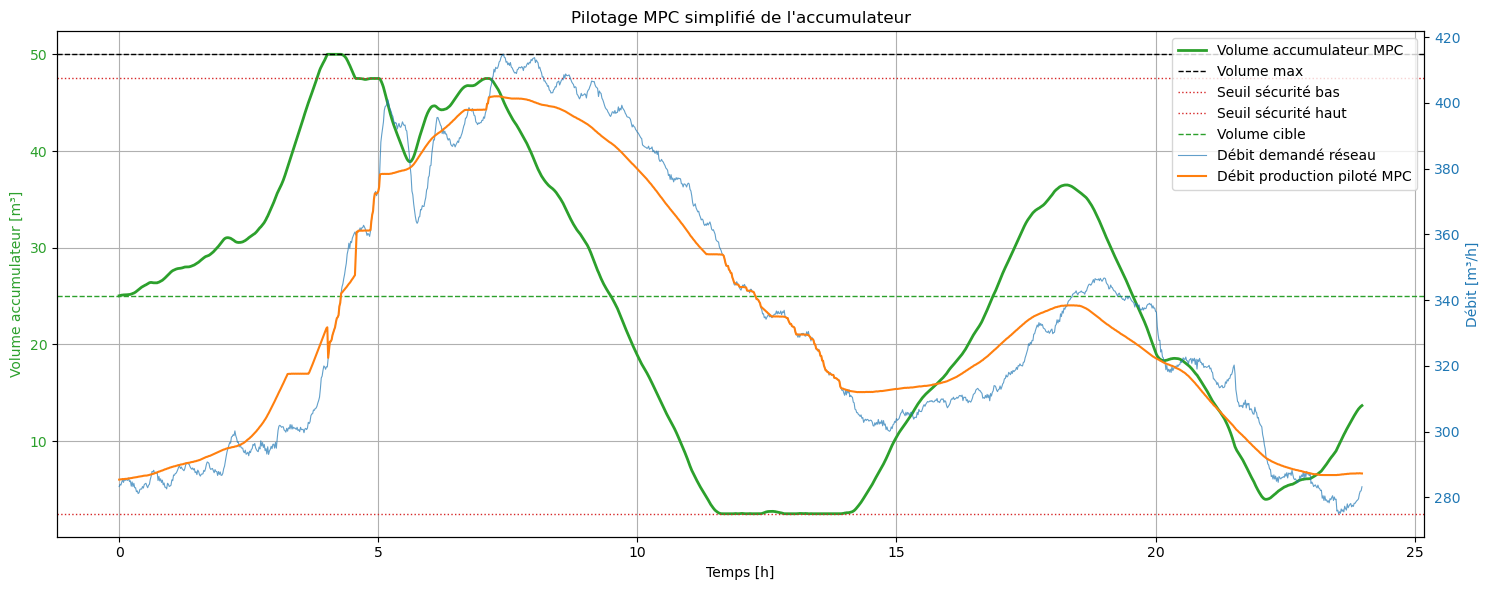

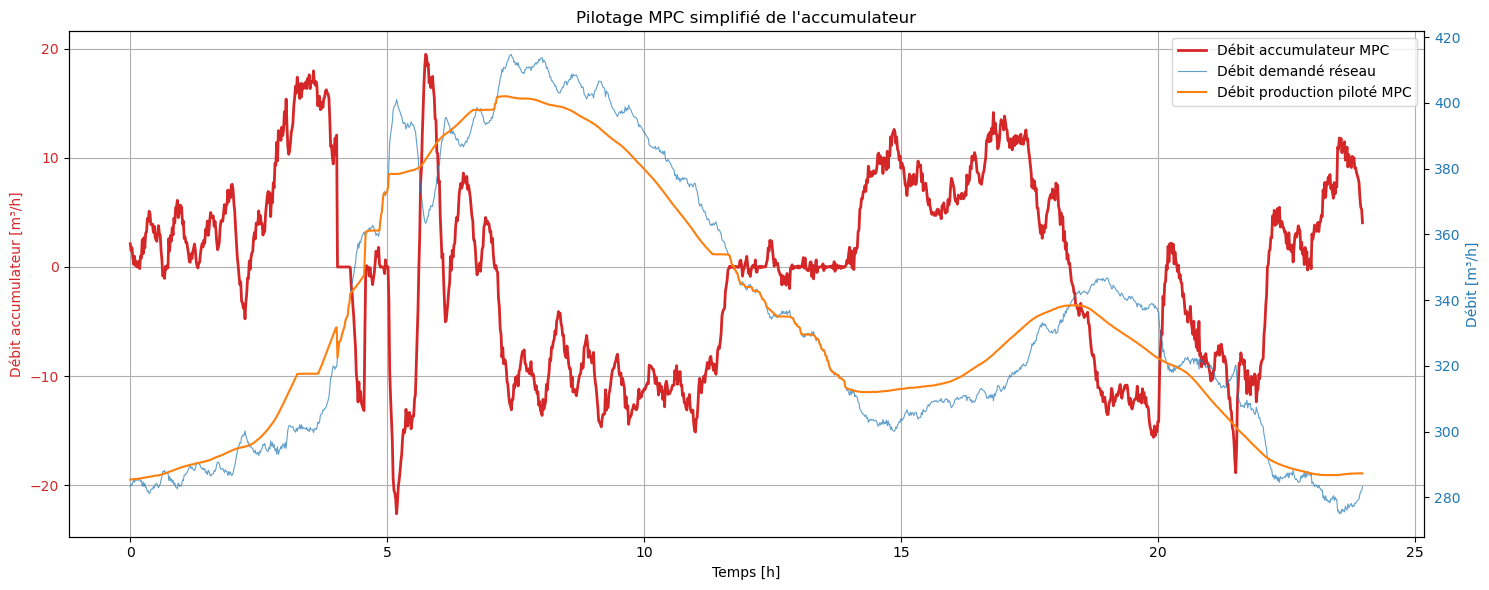

In [32]:

# Série de demande hydraulique [m³/h]
Q_demande = Q_step_4.astype(float).reset_index(drop=True)

# Pas de temps des données
# Si tes données sont minute par minute, garde 1
DT_MIN = 1
DT_H = DT_MIN / 60

# Volume d'accumulation utilisé pour la simulation
Volume_accu_sim = 50

# Volume de l'accumulateur [m³]
V_MAX = Volume_accu_sim
V_MIN_SECURITE = 0.05 * V_MAX
V_MAX_SECURITE = 0.95 * V_MAX
V_CIBLE = 0.50 * V_MAX

# Horizon d'anticipation du MPC [min]
HORIZON_MPC_MIN = 90
HORIZON_STEPS = int(HORIZON_MPC_MIN / DT_MIN)

# Limites de fonctionnement de la STEP / production
# Ici on évite de dimensionner sur les extrêmes absolus.
# Tu peux remplacer par des valeurs physiques si tu les connais.
Q_MIN_PROD = Q_demande.quantile(0.01)
Q_MAX_PROD = Q_demande.quantile(0.99)

# Variation maximale du débit de production [m³/h par minute]
# À ajuster selon la dynamique admissible des pompes / échangeurs
RAMPE_MAX = 10

# Nombre de débits candidats testés à chaque pas
NB_CANDIDATS = 250

# Pondérations de l'objectif MPC
POIDS_VOLUME = 1.0
POIDS_LISSAGE = 0.15
POIDS_SUIVI_DEMANDE = 0.05
POIDS_VIOLATION = 1e6

# ============================================================
# INITIALISATION
# ============================================================

n = len(Q_demande)

V_accu = V_CIBLE
Q_prod_prec = Q_demande.iloc[0]

V_hist = []
SOC_hist = []
Q_prod_hist = []
etat_hist = []
violation_hist = []

# ============================================================
# BOUCLE MPC
# ============================================================

for i in range(n):

    Q_reseau = Q_demande.iloc[i]

    # --------------------------------------------------------
    # 1. Prévision simplifiée de la demande sur l'horizon MPC
    # --------------------------------------------------------
    forecast = Q_demande.iloc[i:i + HORIZON_STEPS].values

    # Si on arrive à la fin de la série, on complète avec la dernière valeur connue
    if len(forecast) < HORIZON_STEPS:
        forecast = np.pad(
            forecast,
            (0, HORIZON_STEPS - len(forecast)),
            mode="edge"
        )

    # --------------------------------------------------------
    # 2. Définition des candidats de débit de production
    # --------------------------------------------------------

    Q_bas = max(Q_MIN_PROD, Q_prod_prec - RAMPE_MAX * DT_MIN)
    Q_haut = min(Q_MAX_PROD, Q_prod_prec + RAMPE_MAX * DT_MIN)

    candidats_Q = np.linspace(Q_bas, Q_haut, NB_CANDIDATS)

    meilleur_cout = np.inf
    meilleur_Q = Q_prod_prec

    # --------------------------------------------------------
    # 3. Optimisation simplifiée sur l'horizon
    # --------------------------------------------------------
    for Q_candidat in candidats_Q:

        # Hypothèse simplifiée :
        # on teste le maintien du débit candidat sur tout l'horizon.
        V_future = V_accu + np.cumsum((Q_candidat - forecast) * DT_H)

        # Ecart au volume cible
        cout_volume = np.mean(((V_future - V_CIBLE) / V_MAX) ** 2)

        # Pénalité si on se rapproche trop des bornes
        violation_basse = np.maximum(V_MIN_SECURITE - V_future, 0)
        violation_haute = np.maximum(V_future - V_MAX_SECURITE, 0)

        cout_violation = (
            np.sum((violation_basse / V_MAX) ** 2)
            + np.sum((violation_haute / V_MAX) ** 2)
        )

        # Lissage de la production
        cout_lissage = ((Q_candidat - Q_prod_prec) / (Q_MAX_PROD - Q_MIN_PROD)) ** 2

        # Éviter de trop s'éloigner de la demande moyenne prévue
        cout_suivi = ((Q_candidat - np.mean(forecast)) / (Q_MAX_PROD - Q_MIN_PROD)) ** 2

        cout_total = (
            POIDS_VOLUME * cout_volume
            + POIDS_LISSAGE * cout_lissage
            + POIDS_SUIVI_DEMANDE * cout_suivi
            + POIDS_VIOLATION * cout_violation
        )

        if cout_total < meilleur_cout:
            meilleur_cout = cout_total
            meilleur_Q = Q_candidat

    Q_prod = meilleur_Q

    # --------------------------------------------------------
    # 4. Protection anti-volume négatif / débordement
    # --------------------------------------------------------

    V_suivant = V_accu + (Q_prod - Q_reseau) * DT_H

    violation = "OK"

    # Si l'accu risque de devenir vide, on force la production à augmenter
    if V_suivant < 0:
        Q_min_necessaire = Q_reseau - V_accu / DT_H
        Q_prod = max(Q_prod, Q_min_necessaire)

        # Respect des limites physiques et de rampe
        Q_prod = min(Q_prod, Q_prod_prec + RAMPE_MAX * DT_MIN)
        Q_prod = min(Q_prod, Q_MAX_PROD)

        violation = "Accu vide évité" if Q_prod >= Q_min_necessaire else "Accu vide"

    # Si l'accu risque de déborder, on force la production à diminuer
    elif V_suivant > V_MAX:
        Q_max_acceptable = Q_reseau + (V_MAX - V_accu) / DT_H
        Q_prod = min(Q_prod, Q_max_acceptable)

        # Respect des limites physiques et de rampe
        Q_prod = max(Q_prod, Q_prod_prec - RAMPE_MAX * DT_MIN)
        Q_prod = max(Q_prod, Q_MIN_PROD)

        violation = "Accu plein évité" if Q_prod <= Q_max_acceptable else "Accu plein"

    # --------------------------------------------------------
    # 5. Mise à jour réelle du volume
    # --------------------------------------------------------

    V_accu = V_accu + (Q_prod - Q_reseau) * DT_H

    # Bornage physique
    if V_accu < 0:
        V_accu = 0
    elif V_accu > V_MAX:
        V_accu = V_MAX

    # Etat qualitatif
    if Q_prod > Q_reseau:
        etat = "Charge"
    elif Q_prod < Q_reseau:
        etat = "Décharge"
    else:
        etat = "Neutre"

    # Sauvegarde
    Q_prod_hist.append(Q_prod)
    V_hist.append(V_accu)
    SOC_hist.append(V_accu / V_MAX)
    etat_hist.append(etat)
    violation_hist.append(violation)

    Q_prod_prec = Q_prod

# ============================================================
# RÉSULTATS
# ============================================================

Q_prod_mpc = pd.Series(Q_prod_hist, index=Q_step_4.index, name="Débit production MPC [m³/h]")
V_accu_mpc = pd.Series(V_hist, index=Q_step_4.index, name="Volume accumulateur [m³]")
SOC_accu_mpc = pd.Series(SOC_hist, index=Q_step_4.index, name="SOC accumulateur [-]")
etat_mpc = pd.Series(etat_hist, index=Q_step_4.index, name="Etat accu")
violation_mpc = pd.Series(violation_hist, index=Q_step_4.index, name="Violation")

# Statistiques rapides
print("=== Résultats MPC simplifié ===")
print(f"Volume min atteint : {V_accu_mpc.min():.1f} m³")
print(f"Volume max atteint : {V_accu_mpc.max():.1f} m³")
print(f"SOC min atteint : {SOC_accu_mpc.min()*100:.1f} %")
print(f"SOC max atteint : {SOC_accu_mpc.max()*100:.1f} %")
print(f"Débit production min : {Q_prod_mpc.min():.1f} m³/h")
print(f"Débit production max : {Q_prod_mpc.max():.1f} m³/h")
print(f"Nombre de pas avec accu vide : {(V_accu_mpc <= 0).sum()}")
print(f"Nombre de pas avec accu plein : {(V_accu_mpc >= V_MAX).sum()}")

# ============================================================
# GRAPHIQUE
# ============================================================

temps_h = np.arange(n) * DT_MIN / 60

fig, ax1 = plt.subplots(figsize=(15, 6))

# Axe gauche : volume accumulateur
ax1.plot(
    temps_h,
    V_accu_mpc,
    color="tab:green",
    linewidth=2,
    label="Volume accumulateur MPC"
)

ax1.axhline(V_MAX, color="black", linestyle="--", linewidth=1, label="Volume max")
ax1.axhline(V_MIN_SECURITE, color="tab:red", linestyle=":", linewidth=1, label="Seuil sécurité bas")
ax1.axhline(V_MAX_SECURITE, color="tab:red", linestyle=":", linewidth=1, label="Seuil sécurité haut")
ax1.axhline(V_CIBLE, color="tab:green", linestyle="--", linewidth=1, label="Volume cible")

ax1.set_xlabel("Temps [h]")
ax1.set_ylabel("Volume accumulateur [m³]", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")
ax1.grid(True)

# Axe droit : débits
ax2 = ax1.twinx()

ax2.plot(
    temps_h,
    Q_demande,
    color="tab:blue",
    linewidth=0.8,
    alpha=0.7,
    label="Débit demandé réseau"
)

ax2.plot(
    temps_h,
    Q_prod_mpc,
    color="tab:orange",
    linewidth=1.5,
    label="Débit production piloté MPC"
)

ax2.set_ylabel("Débit [m³/h]", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title("Pilotage MPC simplifié de l'accumulateur")
plt.tight_layout()
plt.show()


fig2, ax1 = plt.subplots(figsize=(15, 6))

# Axe gauche : débit accumulateur
ax1.plot(
    temps_h,
    Q_prod_mpc - Q_demande,
    color="tab:red",
    linewidth=2,
    label="Débit accumulateur MPC"
)


ax1.set_xlabel("Temps [h]")
ax1.set_ylabel("Débit accumulateur [m³/h]", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True)

# Axe droit : débits
ax2 = ax1.twinx()

ax2.plot(
    temps_h,
    Q_demande,
    color="tab:blue",
    linewidth=0.8,
    alpha=0.7,
    label="Débit demandé réseau"
)

ax2.plot(
    temps_h,
    Q_prod_mpc,
    color="tab:orange",
    linewidth=1.5,
    label="Débit production piloté MPC"
)

ax2.set_ylabel("Débit [m³/h]", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title("Pilotage MPC simplifié de l'accumulateur")
plt.tight_layout()
plt.show()


=== Résultats MPC peak shaving ===
Débit max demandé réseau : 414.8 m³/h
Débit max production MPC : 392.6 m³/h
Réduction du débit max : 22.2 m³/h
Volume min atteint : 10.0 m³
Volume max atteint : 89.9 m³
SOC min atteint : 10.0 %
SOC max atteint : 89.9 %
Nombre de pas optimisation fallback : 0


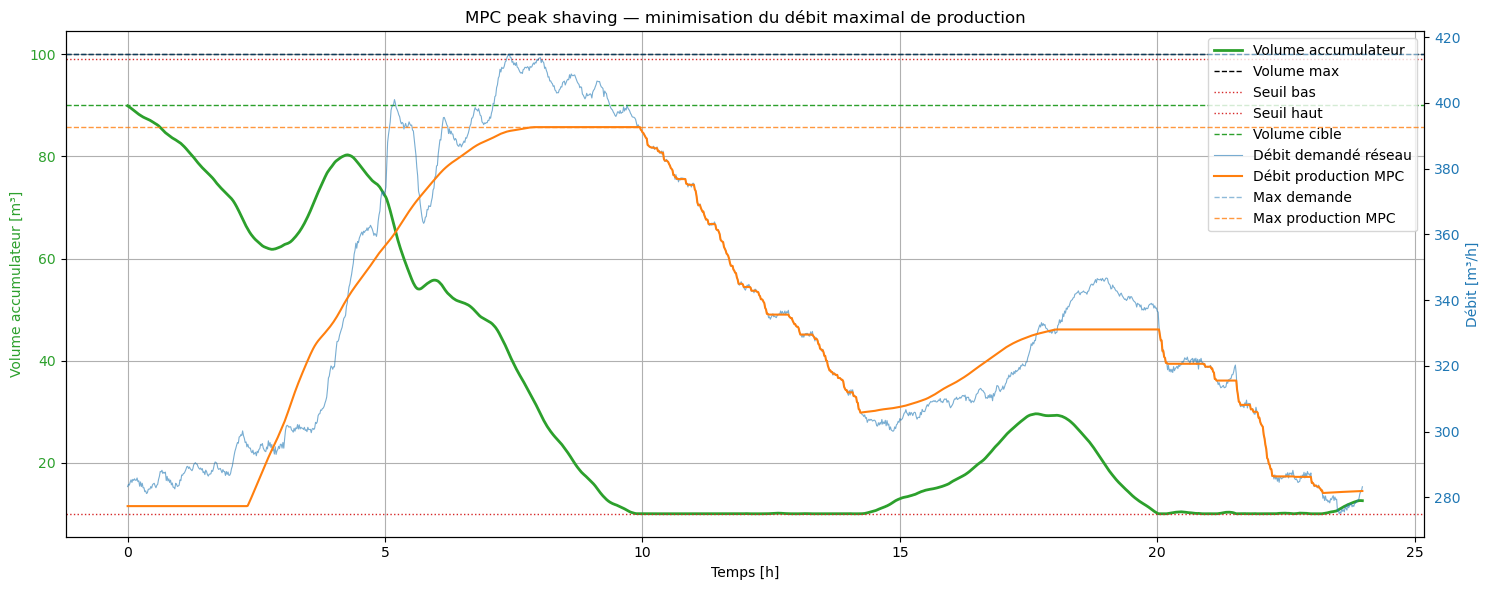

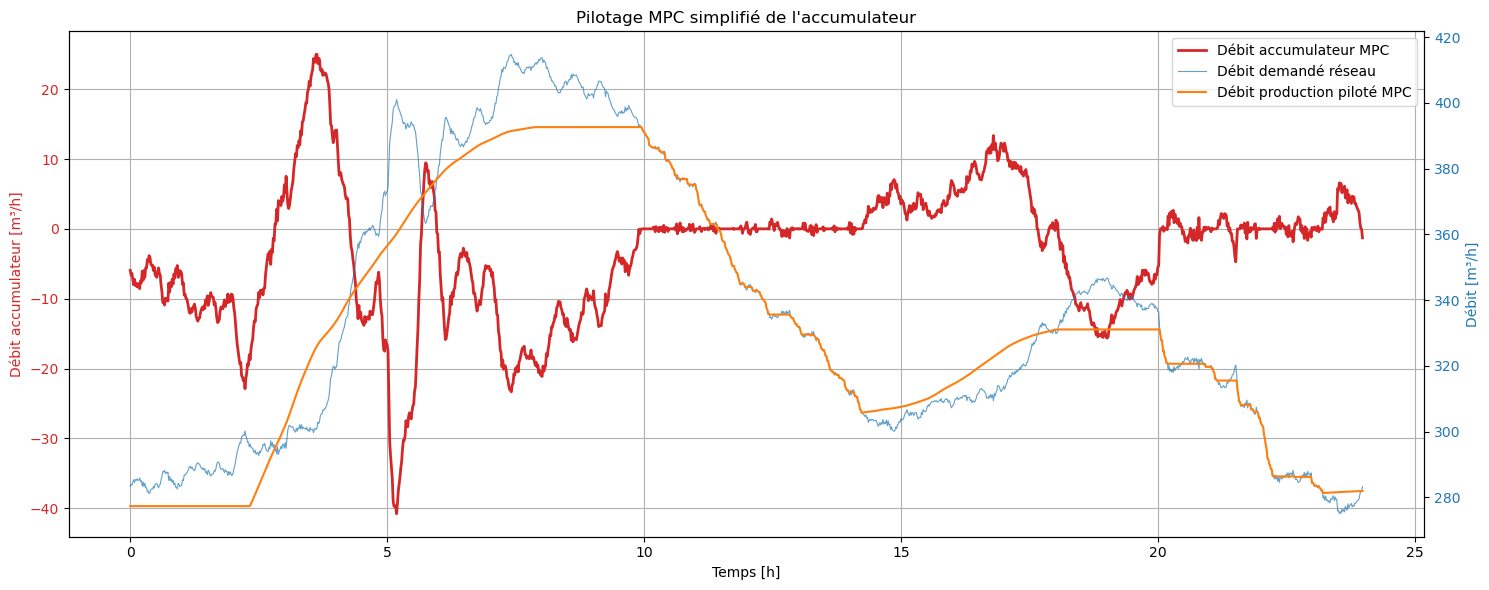

In [28]:
# ============================================================
# MPC PEAK SHAVING
# Objectif : minimiser le débit max de production
# ============================================================

Q_demande = Q_step_4.astype(float).reset_index(drop=True)

# Pas de temps
DT_MIN = 1
DT_H = DT_MIN / 60

# Volume accumulateur
V_MAX = 100
V_MIN = 0.02 * V_MAX
V_SECURITE_BAS = 0.10 * V_MAX
V_SECURITE_HAUT = 0.99 * V_MAX
V_CIBLE = 0.90 * V_MAX

# Horizon MPC
HORIZON_MPC_MIN = 120
H = int(HORIZON_MPC_MIN / DT_MIN)

# Limites de production
Q_MIN_PROD = Q_demande.quantile(0.01)
Q_MAX_PROD = Q_demande.quantile(0.995)

# Rampe maximale admissible [m³/h par minute]
RAMPE_MAX = 15

# Pondérations secondaires
# Le vrai objectif principal reste la minimisation du débit crête.
POIDS_VOLUME_FINAL = 1e-3
POIDS_LISSAGE = 1e-4

n = len(Q_demande)

# Initialisation
V_accu = V_CIBLE
Q_prod_prec = Q_demande.iloc[0]

V_hist = []
Q_prod_hist = []
Q_peak_pred_hist = []
status_hist = []

# ============================================================
# BOUCLE MPC
# ============================================================

for i in range(n):

    # Prévision de la demande sur l'horizon
    forecast = Q_demande.iloc[i:i + H].values

    if len(forecast) < H:
        forecast = np.pad(
            forecast,
            (0, H - len(forecast)),
            mode="edge"
        )

    # --------------------------------------------------------
    # Variables d'optimisation
    # --------------------------------------------------------
    # x = [
    #   q_0 ... q_{H-1},
    #   V_1 ... V_H,
    #   Q_peak,
    #   s_final_plus,
    #   s_final_minus
    # ]
    #
    # q_k : débit de production [m³/h]
    # V_k : volume accumulateur [m³]
    # Q_peak : maximum de production sur l'horizon
    # s_final_plus / minus : relâchement sur le volume final

    nb_q = H
    nb_v = H
    idx_q = 0
    idx_v = nb_q
    idx_peak = nb_q + nb_v
    idx_s_plus = idx_peak + 1
    idx_s_minus = idx_peak + 2

    nb_var = nb_q + nb_v + 3

    # --------------------------------------------------------
    # Fonction objectif
    # --------------------------------------------------------
    c = np.zeros(nb_var)

    # Objectif principal : minimiser le débit maximal
    c[idx_peak] = 1.0

    # Objectif secondaire : éviter de finir trop loin du volume cible
    c[idx_s_plus] = POIDS_VOLUME_FINAL
    c[idx_s_minus] = POIDS_VOLUME_FINAL

    # Petit coût de production pour favoriser les solutions basses
    c[idx_q:idx_q + nb_q] = POIDS_LISSAGE

    # --------------------------------------------------------
    # Bornes des variables
    # --------------------------------------------------------
    bounds = []

    # Bornes q_k
    for k in range(H):
        bounds.append((Q_MIN_PROD, Q_MAX_PROD))

    # Bornes V_k
    for k in range(H):
        bounds.append((V_MIN, V_MAX))

    # Borne Q_peak
    bounds.append((Q_MIN_PROD, Q_MAX_PROD))

    # Slacks volume final
    bounds.append((0, None))
    bounds.append((0, None))

    # --------------------------------------------------------
    # Contraintes d'égalité : dynamique du volume
    # V_{k+1} = V_k + (q_k - demande_k) * DT_H
    # --------------------------------------------------------
    A_eq = []
    b_eq = []

    for k in range(H):

        row = np.zeros(nb_var)

        # V_{k+1}
        row[idx_v + k] = 1.0

        # q_k
        row[idx_q + k] = -DT_H

        if k == 0:
            # V_1 = V_accu + (q_0 - demande_0) * DT_H
            b = V_accu - forecast[k] * DT_H
        else:
            # V_{k+1} = V_k + ...
            row[idx_v + k - 1] = -1.0
            b = -forecast[k] * DT_H

        A_eq.append(row)
        b_eq.append(b)

    # Volume final proche de V_CIBLE :
    # V_H - s_plus + s_minus = V_CIBLE
    row = np.zeros(nb_var)
    row[idx_v + H - 1] = 1.0
    row[idx_s_plus] = -1.0
    row[idx_s_minus] = 1.0

    A_eq.append(row)
    b_eq.append(V_CIBLE)

    # --------------------------------------------------------
    # Contraintes d'inégalité
    # --------------------------------------------------------
    A_ub = []
    b_ub = []

    # q_k <= Q_peak
    for k in range(H):
        row = np.zeros(nb_var)
        row[idx_q + k] = 1.0
        row[idx_peak] = -1.0

        A_ub.append(row)
        b_ub.append(0.0)

    # Rampe entre Q_prod_prec et q_0
    row = np.zeros(nb_var)
    row[idx_q + 0] = 1.0
    A_ub.append(row)
    b_ub.append(Q_prod_prec + RAMPE_MAX * DT_MIN)

    row = np.zeros(nb_var)
    row[idx_q + 0] = -1.0
    A_ub.append(row)
    b_ub.append(-(Q_prod_prec - RAMPE_MAX * DT_MIN))

    # Rampe entre q_k et q_{k-1}
    for k in range(1, H):

        # q_k - q_{k-1} <= RAMPE_MAX
        row = np.zeros(nb_var)
        row[idx_q + k] = 1.0
        row[idx_q + k - 1] = -1.0
        A_ub.append(row)
        b_ub.append(RAMPE_MAX * DT_MIN)

        # q_{k-1} - q_k <= RAMPE_MAX
        row = np.zeros(nb_var)
        row[idx_q + k - 1] = 1.0
        row[idx_q + k] = -1.0
        A_ub.append(row)
        b_ub.append(RAMPE_MAX * DT_MIN)

    # Seuils de sécurité souples sur le volume :
    # on évite de descendre trop bas dans l'horizon
    # mais V_MIN reste la contrainte physique dure.
    for k in range(H):

        # V_k >= V_SECURITE_BAS
        # -V_k <= -V_SECURITE_BAS
        row = np.zeros(nb_var)
        row[idx_v + k] = -1.0
        A_ub.append(row)
        b_ub.append(-V_SECURITE_BAS)

        # V_k <= V_SECURITE_HAUT
        row = np.zeros(nb_var)
        row[idx_v + k] = 1.0
        A_ub.append(row)
        b_ub.append(V_SECURITE_HAUT)

    # --------------------------------------------------------
    # Résolution
    # --------------------------------------------------------
    res = linprog(
        c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        bounds=bounds,
        method="highs"
    )

    if res.success:
        x = res.x
        Q_prod = x[idx_q]
        Q_peak_pred = x[idx_peak]
        status = "Optimal"
    else:
        # Fallback si l'optimisation est infaisable :
        # on produit juste ce qu'il faut pour éviter de vider l'accu.
        Q_prod = Q_demande.iloc[i]

        Q_prod = np.clip(
            Q_prod,
            Q_prod_prec - RAMPE_MAX * DT_MIN,
            Q_prod_prec + RAMPE_MAX * DT_MIN
        )

        Q_prod = np.clip(Q_prod, Q_MIN_PROD, Q_MAX_PROD)

        Q_peak_pred = np.nan
        status = "Fallback"

    # --------------------------------------------------------
    # Mise à jour réelle de l'accumulateur
    # --------------------------------------------------------
    Q_reseau = Q_demande.iloc[i]

    V_accu = V_accu + (Q_prod - Q_reseau) * DT_H

    # Bornes physiques
    V_accu = np.clip(V_accu, 0, V_MAX)

    # Sauvegarde
    Q_prod_hist.append(Q_prod)
    V_hist.append(V_accu)
    Q_peak_pred_hist.append(Q_peak_pred)
    status_hist.append(status)

    Q_prod_prec = Q_prod

# ============================================================
# RÉSULTATS
# ============================================================

Q_prod_peak_mpc = pd.Series(
    Q_prod_hist,
    index=Q_step_4.index,
    name="Débit production MPC peak shaving [m³/h]"
)

V_accu_peak_mpc = pd.Series(
    V_hist,
    index=Q_step_4.index,
    name="Volume accumulateur MPC peak shaving [m³]"
)

Q_peak_pred_mpc = pd.Series(
    Q_peak_pred_hist,
    index=Q_step_4.index,
    name="Débit maximal prédit horizon MPC [m³/h]"
)

status_mpc = pd.Series(
    status_hist,
    index=Q_step_4.index,
    name="Status optimisation"
)

print("=== Résultats MPC peak shaving ===")
print(f"Débit max demandé réseau : {Q_demande.max():.1f} m³/h")
print(f"Débit max production MPC : {Q_prod_peak_mpc.max():.1f} m³/h")
print(f"Réduction du débit max : {Q_demande.max() - Q_prod_peak_mpc.max():.1f} m³/h")
print(f"Volume min atteint : {V_accu_peak_mpc.min():.1f} m³")
print(f"Volume max atteint : {V_accu_peak_mpc.max():.1f} m³")
print(f"SOC min atteint : {100 * V_accu_peak_mpc.min() / V_MAX:.1f} %")
print(f"SOC max atteint : {100 * V_accu_peak_mpc.max() / V_MAX:.1f} %")
print(f"Nombre de pas optimisation fallback : {(status_mpc == 'Fallback').sum()}")

# ============================================================
# GRAPHIQUE
# ============================================================

temps_h = np.arange(n) * DT_MIN / 60

fig, ax1 = plt.subplots(figsize=(15, 6))


# Axe gauche : volume
ax1.plot(
    temps_h,
    V_accu_peak_mpc,
    color="tab:green",
    linewidth=2,
    label="Volume accumulateur"
)

ax1.axhline(V_MAX, color="black", linestyle="--", linewidth=1, label="Volume max")
ax1.axhline(V_SECURITE_BAS, color="tab:red", linestyle=":", linewidth=1, label="Seuil bas")
ax1.axhline(V_SECURITE_HAUT, color="tab:red", linestyle=":", linewidth=1, label="Seuil haut")
ax1.axhline(V_CIBLE, color="tab:green", linestyle="--", linewidth=1, label="Volume cible")

ax1.set_xlabel("Temps [h]")
ax1.set_ylabel("Volume accumulateur [m³]", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")
ax1.grid(True)

# Axe droit : débits
ax2 = ax1.twinx()

ax2.plot(
    temps_h,
    Q_demande,
    color="tab:blue",
    linewidth=0.8,
    alpha=0.6,
    label="Débit demandé réseau"
)

ax2.plot(
    temps_h,
    Q_prod_peak_mpc,
    color="tab:orange",
    linewidth=1.5,
    label="Débit production MPC"
)

ax2.axhline(
    Q_demande.max(),
    color="tab:blue",
    linestyle="--",
    linewidth=1,
    alpha=0.5,
    label="Max demande"
)

ax2.axhline(
    Q_prod_peak_mpc.max(),
    color="tab:orange",
    linestyle="--",
    linewidth=1,
    alpha=0.8,
    label="Max production MPC"
)

ax2.set_ylabel("Débit [m³/h]", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Légende commune
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title("MPC peak shaving — minimisation du débit maximal de production")
plt.tight_layout()
plt.show()

fig2, ax1 = plt.subplots(figsize=(15, 6))

# Axe gauche : débit accumulateur
ax1.plot(
    temps_h,
    Q_prod_peak_mpc - Q_demande,
    color="tab:red",
    linewidth=2,
    label="Débit accumulateur MPC"
)


ax1.set_xlabel("Temps [h]")
ax1.set_ylabel("Débit accumulateur [m³/h]", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True)

# Axe droit : débits
ax2 = ax1.twinx()

ax2.plot(
    temps_h,
    Q_demande,
    color="tab:blue",
    linewidth=0.8,
    alpha=0.7,
    label="Débit demandé réseau"
)

ax2.plot(
    temps_h,
    Q_prod_peak_mpc,
    color="tab:orange",
    linewidth=1.5,
    label="Débit production piloté MPC"
)

ax2.set_ylabel("Débit [m³/h]", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title("Pilotage MPC simplifié de l'accumulateur")
plt.tight_layout()
plt.show()


=== Résultats MPC peak shaving avec contrainte douce sur débit accu ===
Débit max demandé réseau : 414.8 m³/h
Débit max production MPC : 394.4 m³/h
Réduction du débit max : 20.4 m³/h
Volume min atteint : 18.0 m³
Volume max atteint : 99.0 m³
SOC min atteint : 18.0 %
SOC max atteint : 99.0 %
Débit max charge accu : 37.5 m³/h
Débit max décharge accu : 33.8 m³/h
Dépassement max charge accu : 0.0 m³/h
Dépassement max décharge accu : 0.0 m³/h
Nombre de pas avec dépassement charge : 0
Nombre de pas avec dépassement décharge : 0
Nombre de pas optimisation fallback : 0


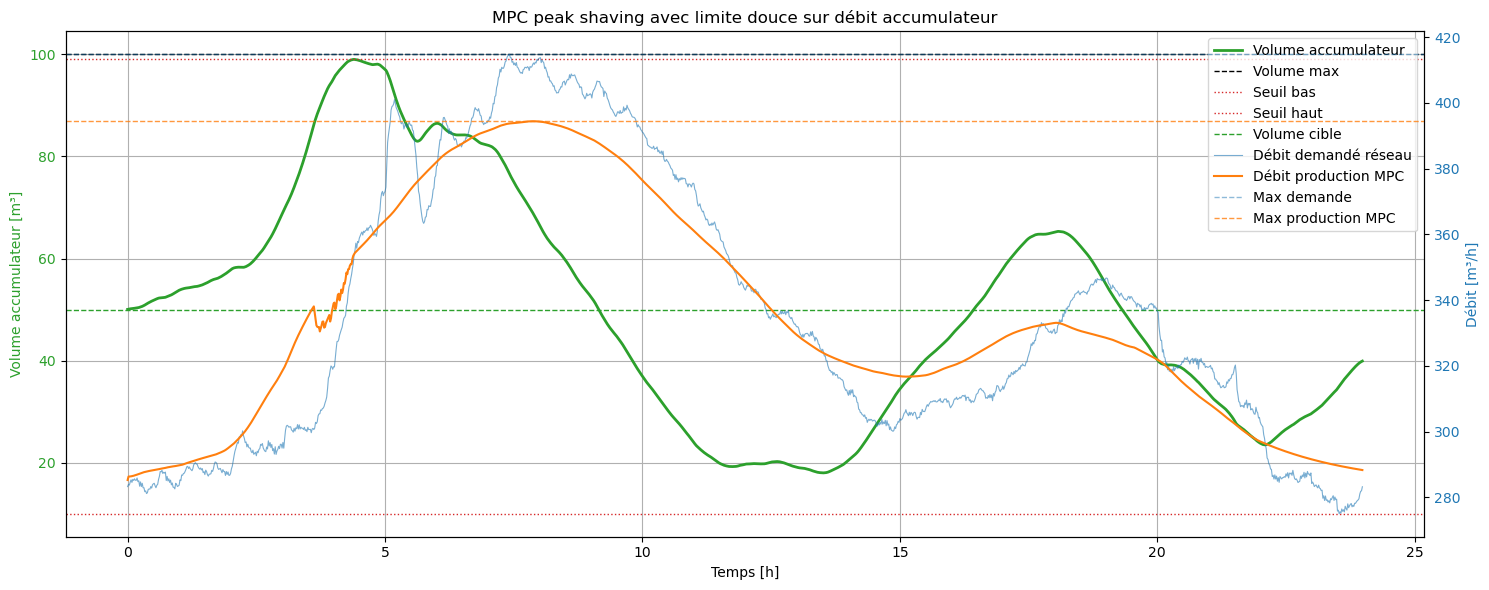

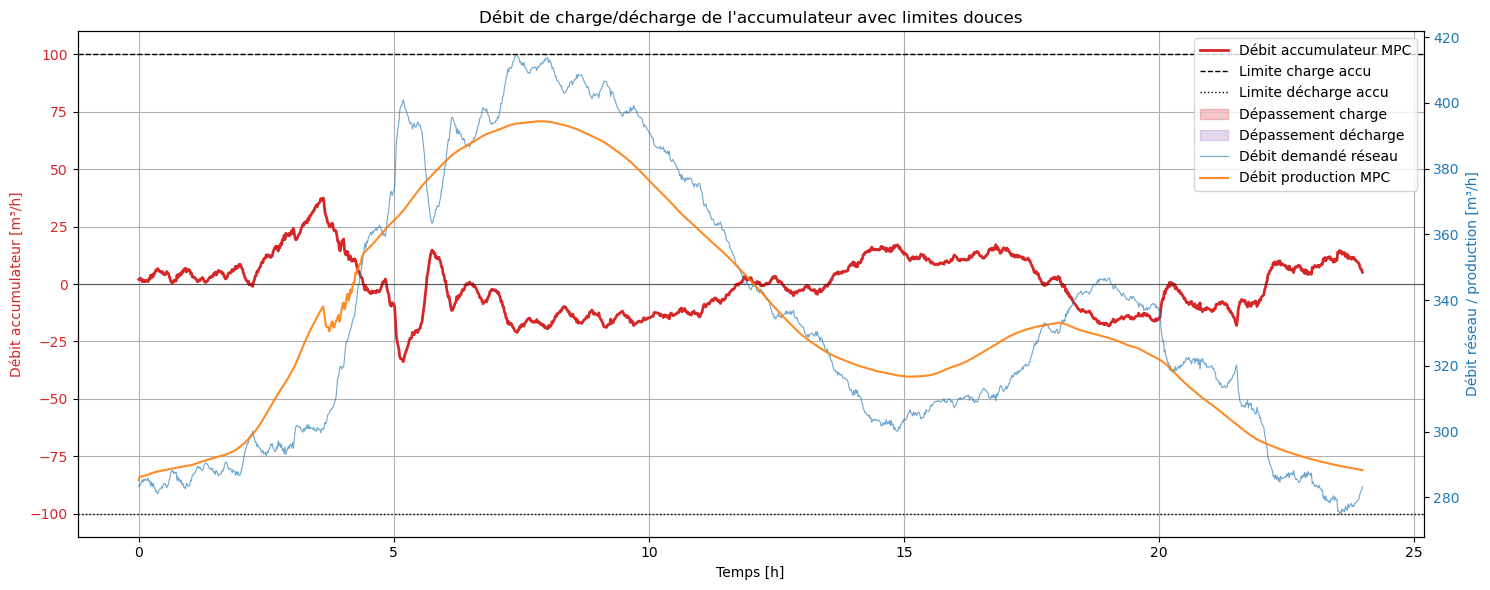

In [38]:
# ============================================================
# MPC PEAK SHAVING AVEC CONTRAINTE DOUCE SUR LE DÉBIT ACCU
# Objectif : minimiser le débit max de production
#            tout en pénalisant les dépassements du débit admissible
#            de charge/décharge de l'accumulateur
# ============================================================

Q_demande = Q_step_4.astype(float).reset_index(drop=True)

# Pas de temps
DT_MIN = 1
DT_H = DT_MIN / 60

# Volume accumulateur
V_MAX = 100
V_MIN = 0.02 * V_MAX
V_SECURITE_BAS = 0.10 * V_MAX
V_SECURITE_HAUT = 0.99 * V_MAX
V_CIBLE = 0.5 * V_MAX

# Horizon MPC
HORIZON_MPC_MIN = 120
H = int(HORIZON_MPC_MIN / DT_MIN)

# Limites de production
Q_MIN_PROD = Q_demande.quantile(0.01)
Q_MAX_PROD = Q_demande.quantile(0.995)

# Rampe maximale admissible [m³/h par minute]
RAMPE_MAX = 2

# ============================================================
# Limites douces de débit dans l'accumulateur
# Convention :
# Q_accu = Q_prod - Q_demande
# Q_accu > 0 : charge accu
# Q_accu < 0 : décharge accu
# ============================================================

# Débit max admissible en charge de l'accu [m³/h]
Q_ACCU_CHARGE_MAX = 100

# Débit max admissible en décharge de l'accu [m³/h]
Q_ACCU_DECHARGE_MAX = 100

# Pénalité sur dépassement des limites de débit accu
# À augmenter si tu veux rendre la contrainte quasi dure.
POIDS_DEPASSEMENT_ACCU = 1e4

# Pondération secondaire sur le retour vers le volume cible
POIDS_VOLUME_FINAL = 1

n = len(Q_demande)

# Initialisation
V_accu = V_CIBLE
Q_prod_prec = Q_demande.iloc[0]

V_hist = []
Q_prod_hist = []
Q_accu_hist = []
Q_peak_pred_hist = []
status_hist = []

# ============================================================
# BOUCLE MPC
# ============================================================

for i in range(n):

    # Prévision de la demande sur l'horizon
    forecast = Q_demande.iloc[i:i + H].values

    if len(forecast) < H:
        forecast = np.pad(
            forecast,
            (0, H - len(forecast)),
            mode="edge"
        )

    # --------------------------------------------------------
    # Variables d'optimisation
    # --------------------------------------------------------
    # x = [
    #   q_0 ... q_{H-1},
    #   V_1 ... V_H,
    #   Q_peak,
    #   s_final_plus,
    #   s_final_minus,
    #   s_charge_0 ... s_charge_{H-1},
    #   s_decharge_0 ... s_decharge_{H-1}
    # ]
    #
    # q_k : débit de production [m³/h]
    # V_k : volume accumulateur [m³]
    # Q_peak : maximum de production sur l'horizon
    # s_final_plus / minus : relâchement sur le volume final
    # s_charge_k : dépassement de la limite de charge accu
    # s_decharge_k : dépassement de la limite de décharge accu

    nb_q = H
    nb_v = H
    nb_s_charge = H
    nb_s_decharge = H

    idx_q = 0
    idx_v = idx_q + nb_q
    idx_peak = idx_v + nb_v
    idx_s_plus = idx_peak + 1
    idx_s_minus = idx_peak + 2
    idx_s_charge = idx_s_minus + 1
    idx_s_decharge = idx_s_charge + nb_s_charge

    nb_var = nb_q + nb_v + 3 + nb_s_charge + nb_s_decharge

    # --------------------------------------------------------
    # Fonction objectif
    # --------------------------------------------------------
    c = np.zeros(nb_var)

    # Objectif principal : minimiser le débit maximal produit
    c[idx_peak] = 1.0

    # Objectif secondaire : éviter de finir trop loin du volume cible
    c[idx_s_plus] = POIDS_VOLUME_FINAL
    c[idx_s_minus] = POIDS_VOLUME_FINAL

    # Pénalité sur dépassement des limites de débit accumulateur
    c[idx_s_charge:idx_s_charge + nb_s_charge] = POIDS_DEPASSEMENT_ACCU
    c[idx_s_decharge:idx_s_decharge + nb_s_decharge] = POIDS_DEPASSEMENT_ACCU

    # --------------------------------------------------------
    # Bornes des variables
    # --------------------------------------------------------
    bounds = []

    # Bornes q_k
    for k in range(H):
        bounds.append((Q_MIN_PROD, Q_MAX_PROD))

    # Bornes V_k
    for k in range(H):
        bounds.append((V_MIN, V_MAX))

    # Borne Q_peak
    bounds.append((Q_MIN_PROD, Q_MAX_PROD))

    # Slacks volume final
    bounds.append((0, None))
    bounds.append((0, None))

    # Slacks dépassement débit accu
    for k in range(H):
        bounds.append((0, None))

    for k in range(H):
        bounds.append((0, None))

    # --------------------------------------------------------
    # Contraintes d'égalité : dynamique du volume
    # V_{k+1} = V_k + (q_k - demande_k) * DT_H
    # --------------------------------------------------------
    A_eq = []
    b_eq = []

    for k in range(H):

        row = np.zeros(nb_var)

        # V_{k+1}
        row[idx_v + k] = 1.0

        # q_k
        row[idx_q + k] = -DT_H

        if k == 0:
            # V_1 = V_accu + (q_0 - demande_0) * DT_H
            b = V_accu - forecast[k] * DT_H
        else:
            # V_{k+1} = V_k + (q_k - demande_k) * DT_H
            row[idx_v + k - 1] = -1.0
            b = -forecast[k] * DT_H

        A_eq.append(row)
        b_eq.append(b)

    # Volume final proche de V_CIBLE :
    # V_H - s_plus + s_minus = V_CIBLE
    row = np.zeros(nb_var)
    row[idx_v + H - 1] = 1.0
    row[idx_s_plus] = -1.0
    row[idx_s_minus] = 1.0

    A_eq.append(row)
    b_eq.append(V_CIBLE)

    # --------------------------------------------------------
    # Contraintes d'inégalité
    # --------------------------------------------------------
    A_ub = []
    b_ub = []

    # q_k <= Q_peak
    for k in range(H):
        row = np.zeros(nb_var)
        row[idx_q + k] = 1.0
        row[idx_peak] = -1.0

        A_ub.append(row)
        b_ub.append(0.0)

    # --------------------------------------------------------
    # Contraintes douces sur le débit accumulateur
    # Q_accu_k = q_k - demande_k
    #
    # Charge :
    # q_k - demande_k <= Q_ACCU_CHARGE_MAX + s_charge_k
    # donc :
    # q_k - s_charge_k <= Q_ACCU_CHARGE_MAX + demande_k
    #
    # Décharge :
    # demande_k - q_k <= Q_ACCU_DECHARGE_MAX + s_decharge_k
    # donc :
    # -q_k - s_decharge_k <= Q_ACCU_DECHARGE_MAX - demande_k
    # --------------------------------------------------------

    for k in range(H):

        # Dépassement en charge
        row = np.zeros(nb_var)
        row[idx_q + k] = 1.0
        row[idx_s_charge + k] = -1.0

        A_ub.append(row)
        b_ub.append(Q_ACCU_CHARGE_MAX + forecast[k])

        # Dépassement en décharge
        row = np.zeros(nb_var)
        row[idx_q + k] = -1.0
        row[idx_s_decharge + k] = -1.0

        A_ub.append(row)
        b_ub.append(Q_ACCU_DECHARGE_MAX - forecast[k])

    # --------------------------------------------------------
    # Rampe entre Q_prod_prec et q_0
    # --------------------------------------------------------

    row = np.zeros(nb_var)
    row[idx_q + 0] = 1.0
    A_ub.append(row)
    b_ub.append(Q_prod_prec + RAMPE_MAX * DT_MIN)

    row = np.zeros(nb_var)
    row[idx_q + 0] = -1.0
    A_ub.append(row)
    b_ub.append(-(Q_prod_prec - RAMPE_MAX * DT_MIN))

    # --------------------------------------------------------
    # Rampe entre q_k et q_{k-1}
    # --------------------------------------------------------

    for k in range(1, H):

        # q_k - q_{k-1} <= RAMPE_MAX
        row = np.zeros(nb_var)
        row[idx_q + k] = 1.0
        row[idx_q + k - 1] = -1.0
        A_ub.append(row)
        b_ub.append(RAMPE_MAX * DT_MIN)

        # q_{k-1} - q_k <= RAMPE_MAX
        row = np.zeros(nb_var)
        row[idx_q + k - 1] = 1.0
        row[idx_q + k] = -1.0
        A_ub.append(row)
        b_ub.append(RAMPE_MAX * DT_MIN)

    # --------------------------------------------------------
    # Seuils de sécurité sur le volume
    # Ici ils sont durs, car V_MIN / V_MAX sont déjà physiques.
    # Si tu veux les rendre doux aussi, il faut ajouter des slacks.
    # --------------------------------------------------------

    for k in range(H):

        # V_k >= V_SECURITE_BAS
        row = np.zeros(nb_var)
        row[idx_v + k] = -1.0
        A_ub.append(row)
        b_ub.append(-V_SECURITE_BAS)

        # V_k <= V_SECURITE_HAUT
        row = np.zeros(nb_var)
        row[idx_v + k] = 1.0
        A_ub.append(row)
        b_ub.append(V_SECURITE_HAUT)

    # --------------------------------------------------------
    # Résolution
    # --------------------------------------------------------

    res = linprog(
        c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        bounds=bounds,
        method="highs"
    )

    if res.success:

        x = res.x
        Q_prod = x[idx_q]
        Q_peak_pred = x[idx_peak]
        status = "Optimal"

    else:

        # Fallback si l'optimisation est infaisable
        Q_prod = Q_demande.iloc[i]

        Q_prod = np.clip(
            Q_prod,
            Q_prod_prec - RAMPE_MAX * DT_MIN,
            Q_prod_prec + RAMPE_MAX * DT_MIN
        )

        Q_prod = np.clip(Q_prod, Q_MIN_PROD, Q_MAX_PROD)

        Q_peak_pred = np.nan
        status = "Fallback"

    # --------------------------------------------------------
    # Mise à jour réelle de l'accumulateur
    # --------------------------------------------------------

    Q_reseau = Q_demande.iloc[i]
    Q_accu = Q_prod - Q_reseau

    V_accu = V_accu + Q_accu * DT_H

    # Bornes physiques
    V_accu = np.clip(V_accu, 0, V_MAX)

    # Sauvegarde
    Q_prod_hist.append(Q_prod)
    Q_accu_hist.append(Q_accu)
    V_hist.append(V_accu)
    Q_peak_pred_hist.append(Q_peak_pred)
    status_hist.append(status)

    Q_prod_prec = Q_prod

# ============================================================
# RÉSULTATS
# ============================================================

Q_prod_peak_mpc = pd.Series(
    Q_prod_hist,
    index=Q_step_4.index,
    name="Débit production MPC peak shaving [m³/h]"
)

Q_accu_peak_mpc = pd.Series(
    Q_accu_hist,
    index=Q_step_4.index,
    name="Débit accumulateur MPC [m³/h]"
)

V_accu_peak_mpc = pd.Series(
    V_hist,
    index=Q_step_4.index,
    name="Volume accumulateur MPC peak shaving [m³]"
)

Q_peak_pred_mpc = pd.Series(
    Q_peak_pred_hist,
    index=Q_step_4.index,
    name="Débit maximal prédit horizon MPC [m³/h]"
)

status_mpc = pd.Series(
    status_hist,
    index=Q_step_4.index,
    name="Status optimisation"
)

depassement_charge = np.maximum(Q_accu_peak_mpc - Q_ACCU_CHARGE_MAX, 0)
depassement_decharge = np.maximum(-Q_accu_peak_mpc - Q_ACCU_DECHARGE_MAX, 0)

print("=== Résultats MPC peak shaving avec contrainte douce sur débit accu ===")
print(f"Débit max demandé réseau : {Q_demande.max():.1f} m³/h")
print(f"Débit max production MPC : {Q_prod_peak_mpc.max():.1f} m³/h")
print(f"Réduction du débit max : {Q_demande.max() - Q_prod_peak_mpc.max():.1f} m³/h")
print(f"Volume min atteint : {V_accu_peak_mpc.min():.1f} m³")
print(f"Volume max atteint : {V_accu_peak_mpc.max():.1f} m³")
print(f"SOC min atteint : {100 * V_accu_peak_mpc.min() / V_MAX:.1f} %")
print(f"SOC max atteint : {100 * V_accu_peak_mpc.max() / V_MAX:.1f} %")
print(f"Débit max charge accu : {Q_accu_peak_mpc.max():.1f} m³/h")
print(f"Débit max décharge accu : {-Q_accu_peak_mpc.min():.1f} m³/h")
print(f"Dépassement max charge accu : {depassement_charge.max():.1f} m³/h")
print(f"Dépassement max décharge accu : {depassement_decharge.max():.1f} m³/h")
print(f"Nombre de pas avec dépassement charge : {(depassement_charge > 1e-6).sum()}")
print(f"Nombre de pas avec dépassement décharge : {(depassement_decharge > 1e-6).sum()}")
print(f"Nombre de pas optimisation fallback : {(status_mpc == 'Fallback').sum()}")

# ============================================================
# GRAPHIQUE 1 : VOLUME + DÉBITS
# ============================================================

temps_h = np.arange(n) * DT_MIN / 60

fig, ax1 = plt.subplots(figsize=(15, 6))

# Axe gauche : volume
ax1.plot(
    temps_h,
    V_accu_peak_mpc,
    color="tab:green",
    linewidth=2,
    label="Volume accumulateur"
)

ax1.axhline(
    V_MAX,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Volume max"
)

ax1.axhline(
    V_SECURITE_BAS,
    color="tab:red",
    linestyle=":",
    linewidth=1,
    label="Seuil bas"
)

ax1.axhline(
    V_SECURITE_HAUT,
    color="tab:red",
    linestyle=":",
    linewidth=1,
    label="Seuil haut"
)

ax1.axhline(
    V_CIBLE,
    color="tab:green",
    linestyle="--",
    linewidth=1,
    label="Volume cible"
)

ax1.set_xlabel("Temps [h]")
ax1.set_ylabel("Volume accumulateur [m³]", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")
ax1.grid(True)

# Axe droit : débits
ax2 = ax1.twinx()

ax2.plot(
    temps_h,
    Q_demande,
    color="tab:blue",
    linewidth=0.8,
    alpha=0.6,
    label="Débit demandé réseau"
)

ax2.plot(
    temps_h,
    Q_prod_peak_mpc,
    color="tab:orange",
    linewidth=1.5,
    label="Débit production MPC"
)

ax2.axhline(
    Q_demande.max(),
    color="tab:blue",
    linestyle="--",
    linewidth=1,
    alpha=0.5,
    label="Max demande"
)

ax2.axhline(
    Q_prod_peak_mpc.max(),
    color="tab:orange",
    linestyle="--",
    linewidth=1,
    alpha=0.8,
    label="Max production MPC"
)

ax2.set_ylabel("Débit [m³/h]", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Légende commune
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title("MPC peak shaving avec limite douce sur débit accumulateur")
plt.tight_layout()
plt.show()


# ============================================================
# GRAPHIQUE 2 : DÉBIT ACCUMULATEUR + LIMITES DE CHARGE/DÉCHARGE
# ============================================================

fig2, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(
    temps_h,
    Q_accu_peak_mpc,
    color="tab:red",
    linewidth=2,
    label="Débit accumulateur MPC"
)

ax1.axhline(
    0,
    color="black",
    linestyle="-",
    linewidth=0.8,
    alpha=0.5
)

ax1.axhline(
    Q_ACCU_CHARGE_MAX,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Limite charge accu"
)

ax1.axhline(
    -Q_ACCU_DECHARGE_MAX,
    color="black",
    linestyle=":",
    linewidth=1,
    label="Limite décharge accu"
)

# Zones de dépassement en charge
ax1.fill_between(
    temps_h,
    Q_ACCU_CHARGE_MAX,
    Q_accu_peak_mpc,
    where=Q_accu_peak_mpc > Q_ACCU_CHARGE_MAX,
    color="tab:red",
    alpha=0.25,
    label="Dépassement charge"
)

# Zones de dépassement en décharge
ax1.fill_between(
    temps_h,
    -Q_ACCU_DECHARGE_MAX,
    Q_accu_peak_mpc,
    where=Q_accu_peak_mpc < -Q_ACCU_DECHARGE_MAX,
    color="tab:purple",
    alpha=0.25,
    label="Dépassement décharge"
)

ax1.set_xlabel("Temps [h]")
ax1.set_ylabel("Débit accumulateur [m³/h]", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True)

# Axe droit : débits réseau / production
ax2 = ax1.twinx()

ax2.plot(
    temps_h,
    Q_demande,
    color="tab:blue",
    linewidth=0.8,
    alpha=0.65,
    label="Débit demandé réseau"
)

ax2.plot(
    temps_h,
    Q_prod_peak_mpc,
    color="tab:orange",
    linewidth=1.5,
    alpha=0.9,
    label="Débit production MPC"
)

ax2.set_ylabel("Débit réseau / production [m³/h]", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title("Débit de charge/décharge de l'accumulateur avec limites douces")
plt.tight_layout()
plt.show()

## Ancienne version


La duréee médiane entre deux changement de point d'opération est de : 5.0 s
Le pont d'opération change en moins de : 18.0 s dans 90% des cas
La variation de débit médiane entre deux points d'opération est de : 2.299999999999997 m3/h
Le quantile à 90% de la variation de débit est de : 2.3000000000000114 m3/h
   Durée [min]  N pas  ΔQ90 [m³/h]  Volume [m³]
0            5     60         31.5     5.250000
1           10    120         38.3    12.766667
2           15    180         40.5    20.250000
3           20    240         42.8    28.533333
4           25    300         47.2    39.333333
5           30    360         49.5    49.500000
6           35    420         51.7    60.316667
7           40    480         54.0    72.000000
8           45    540         56.2    84.300000
9           60    720         60.7   121.400000
Le volume nécessaire pour atténuer 90% des fluctuations qui peuvent avoir lieu dans un interval de  60.0 min  est de 121.4  m3, avec un facteur de sécurité de  2


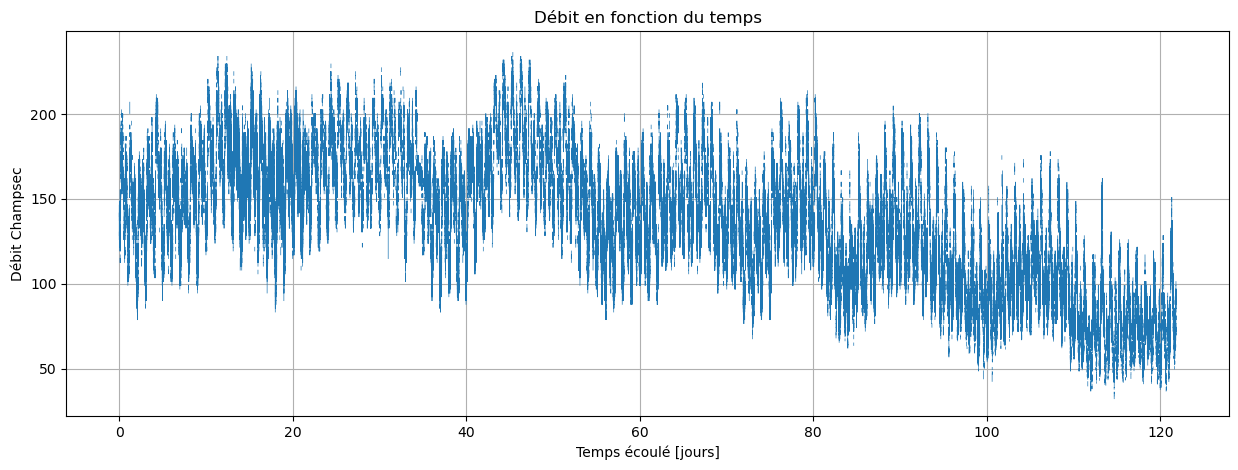

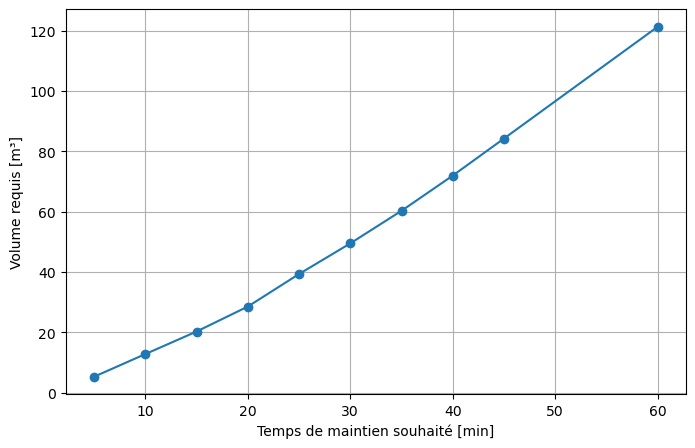

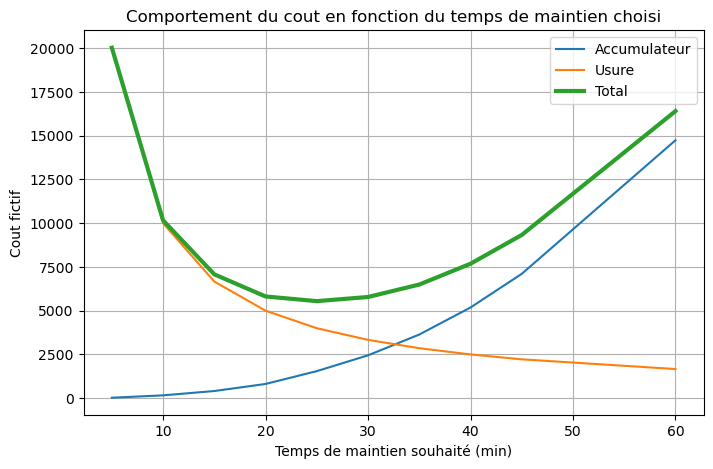

In [15]:

# Extraction des données depuis les données brutes
donnees_secondes = donnees_secondes_raw.copy()
donnees_secondes.columns = ["Date", "Débit Hôpital", "Débit Champsec"]

# Introduction de l'echelle de temps relative
donnees_secondes["Date"] = pd.to_datetime(donnees_secondes["Date"])

t0 = donnees_secondes["Date"].min()
donnees_secondes["Temps_s"] = (
    donnees_secondes["Date"] - t0
).dt.total_seconds()

# Données de débit au format temporel -> passage au format numérique
donnees_secondes["Débit Champsec"] = pd.to_numeric(
    donnees_secondes["Débit Champsec"],
    errors="coerce")
donnees_secondes["Débit Hôpital"] = pd.to_numeric(
    donnees_secondes["Débit Hôpital"],
    errors="coerce")

# Caractéritiques
dt_median = donnees_secondes["Temps_s"].diff().median()
dt_90 = donnees_secondes["Temps_s"].diff().quantile(0.9)
dQ_median = donnees_secondes["Débit Champsec"].diff().abs().median()
dQ_90 = donnees_secondes["Débit Champsec"].diff().abs().quantile(0.9)

print("La duréee médiane entre deux changement de point d'opération est de :", dt_median, "s")
print("Le pont d'opération change en moins de :" , dt_90, "s dans 90% des cas")
print("La variation de débit médiane entre deux points d'opération est de :" , dQ_median, "m3/h")
print("Le quantile à 90% de la variation de débit est de :" , dQ_90, "m3/h")


# facteur de sécurité f
f = 2

# augmentation de la durée de maintien du mode d'opération

# Durées à tester [min]
durees = [5, 10, 15, 20, 25, 30, 35, 40, 45, 60]

resultats = []

for duree in durees:

    dt_cible = duree * 60  # s

    # Nombre de pas correspondant à cette durée
    N = int(dt_cible / dt_median)

    # Variation de débit sur cette durée
    dQ = (
        donnees_secondes["Débit Champsec"]
        - donnees_secondes["Débit Champsec"].shift(N)
    ).abs()

    dQ_90 = dQ.quantile(0.99)

    # Volume nécessaire [m³]
    volume = f * dQ_90 * dt_cible / 3600

    resultats.append({
        "Durée [min]": duree,
        "N pas": N,
        "ΔQ90 [m³/h]": dQ_90,
        "Volume [m³]": volume
    })

resultats = pd.DataFrame(resultats)

print(resultats)

print("Le volume nécessaire pour atténuer 90% des fluctuations qui peuvent avoir lieu dans un interval de ", dt_cible/60, "min  est de", volume, " m3, avec un facteur de sécurité de ", f)

# Visualisation
plt.figure(figsize=(15,5))

plt.plot(
    donnees_secondes["Temps_s"]/(3600*24),
    donnees_secondes["Débit Champsec"],
    linewidth = 0.5
)
plt.title("Débit en fonction du temps")
plt.xlabel("Temps écoulé [jours]")
plt.ylabel("Débit Champsec")
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    resultats["Durée [min]"],
    resultats["Volume [m³]"],
    marker="o"
)

plt.xlabel("Temps de maintien souhaité [min]")
plt.ylabel("Volume requis [m³]")
plt.grid()

plt.show()

# Constantes de prix
alpha = 1
beta = 100000

resultats["C_accu"] = alpha*resultats["Volume [m³]"]**2

resultats["C_switch"] = beta/resultats["Durée [min]"]

resultats["C_total"] = (
    alpha*resultats["Volume [m³]"]**2
    + beta/resultats["Durée [min]"]
)


plt.figure(figsize=(8,5))

plt.plot(
    resultats["Durée [min]"],
    resultats["C_accu"],
    label="Accumulateur"
)

plt.plot(
    resultats["Durée [min]"],
    resultats["C_switch"],
    label="Usure"
)

plt.plot(
    resultats["Durée [min]"],
    resultats["C_total"],
    linewidth=3,
    label="Total"
)

plt.legend()
plt.grid()
plt.title("Comportement du cout en fonction du temps de maintien choisi")
plt.xlabel("Temps de maintien souhaité (min)")
plt.ylabel("Cout fictif")
plt.show()


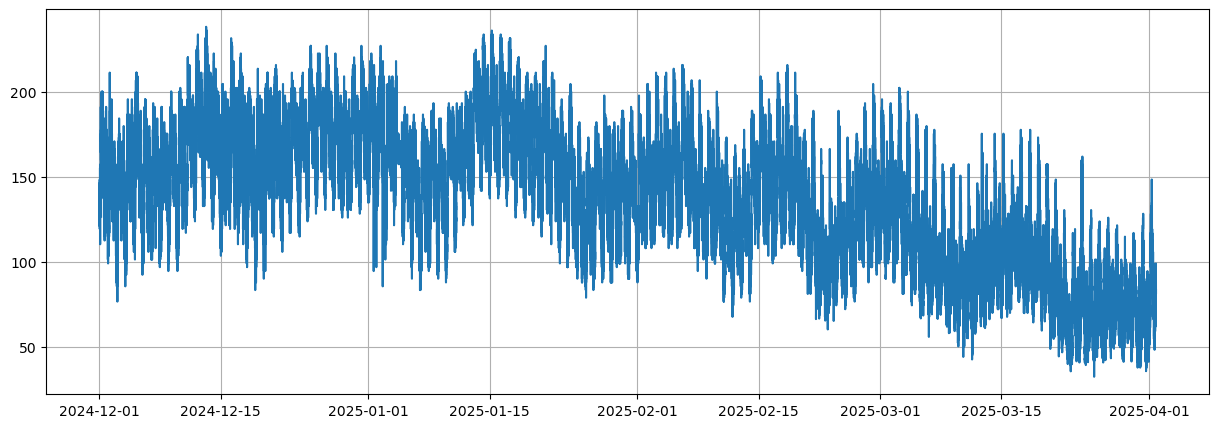

                          mean        std  count      IC_inf      IC_sup
Minute journalière                                                      
0.0                 110.107377  28.530952    122  105.858225  114.356529
1.0                 110.468852  28.085601    122  106.286027  114.651678
2.0                 110.400820  29.135547    122  106.061625  114.740015
3.0                 110.994262  29.334016    122  106.625509  115.363016
4.0                 111.314754  29.977338    122  106.850190  115.779318
...                        ...        ...    ...         ...         ...
1435.0              108.389256  27.504999    121  104.276009  112.502504
1436.0              109.312397  27.948752    121  105.132788  113.492006
1437.0              109.485950  27.791345    121  105.329881  113.642020
1438.0              109.388430  28.139629    121  105.180276  113.596583
1439.0              110.106612  28.196547    121  105.889946  114.323277

[1440 rows x 5 columns]
Le volume de stockage jour

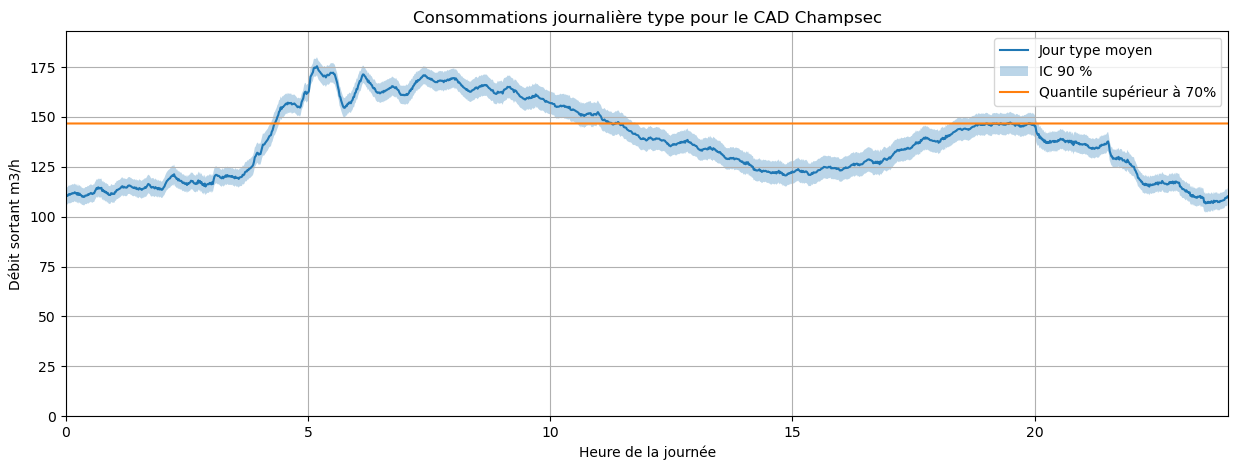

In [16]:
# Extraction des données depuis les données brutes
donnees_minutes = donnees_minutes_raw.copy()
donnees_minutes.columns = ["Date", "Débit Hôpital", "Débit Champsec"]

# Introduction de l'echelle de temps relative
donnees_minutes["Date"] = pd.to_datetime(donnees_minutes["Date"])

t0 = donnees_minutes["Date"].min()
donnees_minutes["Temps_min"] = (
    donnees_minutes["Date"] - t0
).dt.total_seconds()/60

donnees_minutes["Débit Champsec"] = pd.to_numeric(
    donnees_minutes["Débit Champsec"],
    errors="coerce"
)
donnees_minutes["Débit Hôpital"] = pd.to_numeric(
    donnees_minutes["Débit Hôpital"],
    errors="coerce"
)

# Visualisation

plt.figure(figsize=(15,5))

plt.plot(
    donnees_minutes["Date"],
    donnees_minutes["Débit Champsec"]
)

plt.grid()
plt.show()

# Création d'une journée type pour le CAD de Champsec
donnees_minutes["Minute journalière"] = donnees_minutes["Temps_min"] % (24*60)

stats_jour = (
    donnees_minutes
    .groupby("Minute journalière")["Débit Champsec"]
    .agg(["mean", "std", "count"])
)

stats_jour["IC_inf"] = (
    stats_jour["mean"]
    - 1.645 * stats_jour["std"] / stats_jour["count"]**0.5
)

stats_jour["IC_sup"] = (
    stats_jour["mean"]
    + 1.645 * stats_jour["std"] / stats_jour["count"]**0.5
)

print(stats_jour)

plt.figure(figsize=(15,5))

plt.plot(
    stats_jour.index/60,
    stats_jour["mean"],
    label="Jour type moyen"
)

plt.fill_between(
    stats_jour.index/60,
    stats_jour["IC_inf"],
    stats_jour["IC_sup"],
    alpha=0.3,
    label="IC 90 %"
)
plt.xlim([0,24])
plt.ylim([0,stats_jour["mean"].max()*1.1])
plt.title("Consommations journalière type pour le CAD Champsec")
plt.xlabel("Heure de la journée")
plt.ylabel("Débit sortant m3/h")
plt.grid()

# Quantile de stockage paramétrable
Amplitude_stockage = 0.7

plt.plot(stats_jour.index/60, stats_jour["mean"].quantile(Amplitude_stockage)*np.ones(len(stats_jour["mean"])), label="Quantile supérieur à 70%")
plt.legend()

volume_stockage_journalier = 0
longueur_pic = 0
for i in range(len(stats_jour["mean"])):
    if stats_jour["mean"].loc[i] > stats_jour["mean"].quantile(Amplitude_stockage):
        volume_stockage_journalier = volume_stockage_journalier + (stats_jour["mean"].loc[i] -stats_jour["mean"].quantile(Amplitude_stockage))/60
        longueur_pic = longueur_pic + 1 
    
print("Le volume de stockage journalier est de", volume_stockage_journalier, "m3")
print("La durée du pic atténué est de", longueur_pic, "min")

Le volume de stockage journalier est de 44.4068743169399 m3
La durée du pic atténué est de 288 min, soit 4.8 heures


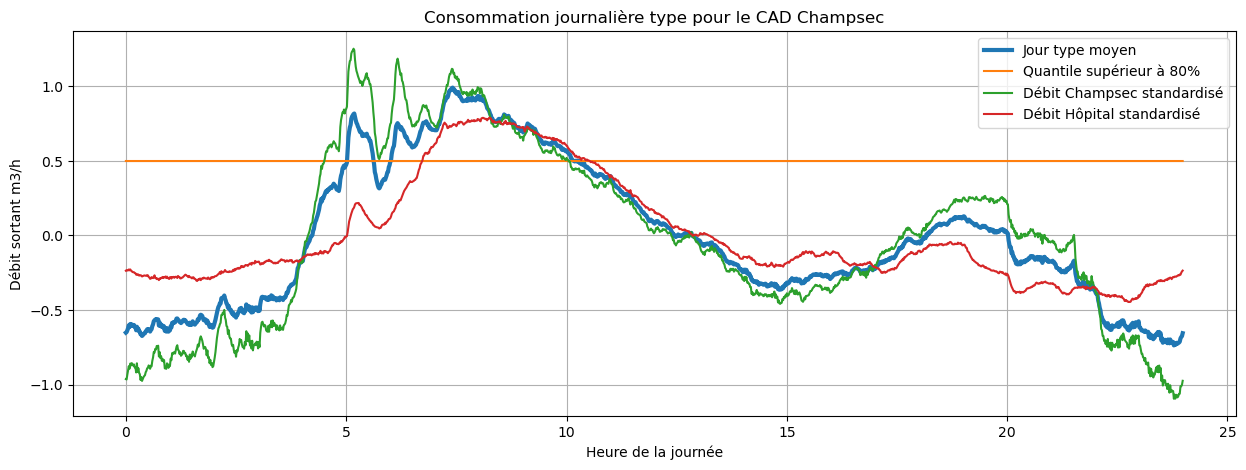

In [17]:
# Création d'une journée type standardisée en sommant champsec et hoptial
donnees_minutes["Débit total"] = donnees_minutes["Débit Champsec"] + donnees_minutes["Débit Hôpital"]
stats_jour_total = (
    donnees_minutes
    .groupby("Minute journalière")["Débit total"]
    .agg(["mean", "std", "count"])
)

jour_standardized = (stats_jour_total["mean"] - stats_jour_total["mean"].mean())/stats_jour_total["std"]

stats_jour_hopital = (
    donnees_minutes
    .groupby("Minute journalière")["Débit Hôpital"]
    .agg(["mean", "std", "count"]) 
)

hopital_journalier_standardized = (stats_jour_hopital["mean"] - stats_jour_hopital["mean"].mean())/stats_jour_hopital["std"]

stats_jour_total["IC_inf"] = (
    jour_standardized
    - 1.645 * stats_jour_total["std"] / stats_jour_total["count"]**0.5
)

stats_jour_total["IC_sup"] = (
    jour_standardized
    + 1.645 * stats_jour_total["std"] / stats_jour_total["count"]**0.5
)


plt.figure(figsize=(15,5))

plt.plot(
    jour_standardized.index/60,
    jour_standardized,
    label="Jour type moyen",
    linewidth = 3
)

plt.title("Consommation journalière type pour le CAD Champsec")
plt.xlabel("Heure de la journée")
plt.ylabel("Débit sortant m3/h")
plt.grid()

Amplitude_stockage = 0.80

plt.plot(jour_standardized.index/60, jour_standardized.quantile(Amplitude_stockage)*np.ones(len(stats_jour["mean"])), label="Quantile supérieur à 80%")
plt.plot(stats_jour.index/60, (stats_jour["mean"]-stats_jour["mean"].mean())/stats_jour["std"], label="Débit Champsec standardisé")
plt.plot(stats_jour_hopital.index/60, (stats_jour_hopital["mean"]-stats_jour_hopital["mean"].mean())/stats_jour_hopital["std"], label="Débit Hôpital standardisé")

plt.legend()

# Série de débit moyen du jour type
Q = stats_jour_total["mean"]

# Seuil de stockage, par exemple quantile 80 %
seuil = Q.quantile(Amplitude_stockage)

# Excès au-dessus du seuil
exces = (Q - seuil).clip(lower=0)

# Volume journalier à stocker [m³]
volume_stockage_journalier_total = exces.sum() / 60

# Longueur totale du pic [min]
longueur_pic_total = (Q > seuil).sum()

    
print("Le volume de stockage journalier est de", volume_stockage_journalier_total, "m3")
print("La durée du pic atténué est de", longueur_pic_total, "min, soit", longueur_pic_total/60,"heures")




Le volume de stockage journalier est de 65.31719804807858 m3
La durée du pic atténué est de 216 min, soit 3.6 heures


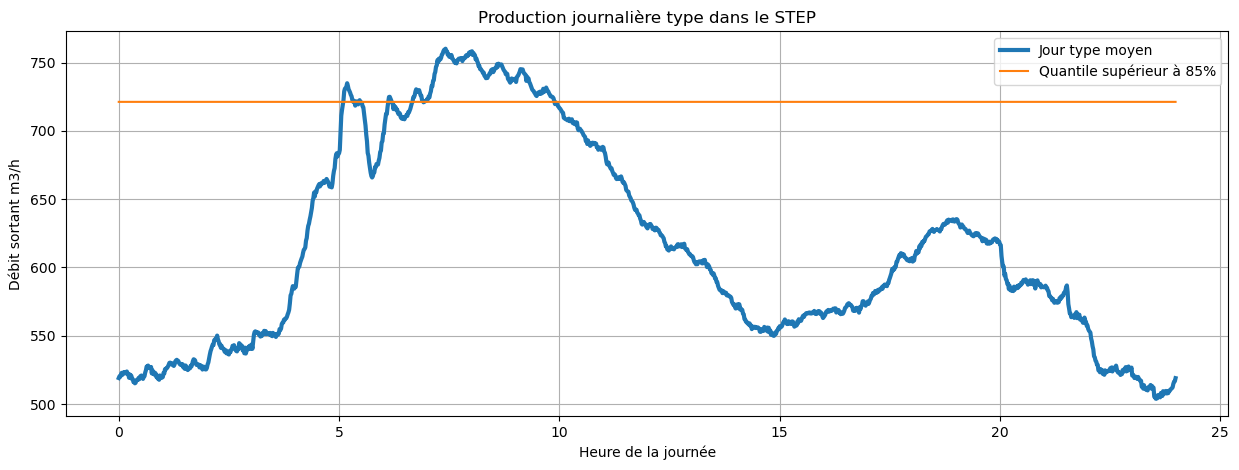

In [18]:
debit_max_champsec = 208.1 # m3/h
debit_max_hopital = 132.1 # m3/h
debit_max_STEP_4 = 724 + 244 # m3/h
debit_total_max = debit_max_champsec + debit_max_hopital

debit_moyen_STEP_4 = stats_jour_total["mean"]/debit_total_max * debit_max_STEP_4


amplitude_stockage_STEP_4 = 0.85


# Seuil de stockage, par exemple quantile 80 %
seuil_STEP_4 = debit_moyen_STEP_4.quantile(amplitude_stockage_STEP_4)

# Excès au-dessus du seuil
exces_STEP_4 = (debit_moyen_STEP_4 - seuil_STEP_4).clip(lower=0)

# Volume journalier à stocker [m³]
volume_stockage_journalier_STEP_4 = exces_STEP_4.sum() / 60

# Longueur totale du pic [min]
longueur_pic_STEP_4= (debit_moyen_STEP_4 > seuil_STEP_4).sum()

print("Le volume de stockage journalier est de", volume_stockage_journalier_STEP_4, "m3")
print("La durée du pic atténué est de", longueur_pic_STEP_4, "min, soit", longueur_pic_STEP_4/60,"heures")

plt.figure(figsize=(15,5))

plt.plot(
    debit_moyen_STEP_4.index/60,
    debit_moyen_STEP_4,
    label="Jour type moyen",
    linewidth = 3
)

plt.title("Production journalière type dans le STEP")
plt.xlabel("Heure de la journée")
plt.ylabel("Débit sortant m3/h")
plt.grid()

plt.plot(debit_moyen_STEP_4.index/60, debit_moyen_STEP_4.quantile(amplitude_stockage_STEP_4)*np.ones(len(debit_moyen_STEP_4)), label="Quantile supérieur à 85%")

plt.legend()


In [19]:
D_STEP_4 = (8*volume_stockage_journalier_STEP_4/np.pi)**(1/3)
D_STEP_4


np.float64(5.499491732780369)

In [20]:
Q_champsec.max()

175.37540983606556

np.float64(1.3051111111111113)